# Trabajo parcial — EDA y propuesta de modelización

**Curso:** CC219, Aplicaciones de Data Science. **Datos:** SemEval-2016 Task 5, restaurantes en español, Subtask 1 (ABSA a nivel de oración).

Este cuaderno desarrolla el EDA, la preparación exploratoria y, al final, la sección 4 de propuesta de modelización. La numeración interna del EDA se conserva. No se entrenan modelos. El archivo original estaba vacío; no había secciones previas que preservar. Ejecutar desde el directorio que contiene `dataset/`, con un kernel Python que disponga de **pandas, numpy y matplotlib** (además de IPython/Jupyter). No requiere descargas de corpus ni modelos.

### Fuentes locales y alcance

Se revisaron el enunciado `CC219-TP-TF-Enunciado-2026-02.docx` (estructura del informe y primer hito) y las presentaciones del directorio:

- **Sesión 1 — Aplicaciones DS**, diapositivas 3–6 y 16–21: XML semiestructurado, comprensión de datos, calidad, EDA, preparación y separación Train/Validation/Test.
- **Sesión 2 — Fundamentos NLP, TF_IDF, Clasificación**, diapositivas 5 y 10–16: normalización, tokenización, stopwords, POS y lematización; el flujo se adapta a la tarea.
- **Sesión 3 — Representaciones Semánticas del Lenguaje**, diapositivas 12–22: significado contextual y límites de frecuencias léxicas.
- **Sesión 4 — Modelos preentrenados para NLP**, diapositivas 4 y 9–13: importancia del contexto y la atención. Justifica conservar información lingüística para decisiones posteriores.
- Las presentaciones de semanas 5 (LLM) y 6 (búsqueda semántica) tratan etapas posteriores; no justifican incorporar modelos en este EDA.

El enunciado exige **carga, inspección, preprocesamiento/normalización y visualización**. Se cubren explícitamente en las secciones siguientes. No se implementan representaciones aprendidas ni clasificadores.

**Unidad de análisis:** las polaridades y los aspectos pertenecen a opiniones, no necesariamente a toda la oración. Las longitudes y frecuencias léxicas se calculan sobre oraciones, una sola vez por elemento XML. `test` se utiliza únicamente para descripción y evaluación futura; no guía ajustes ni selección de transformaciones aprendidas.

## 1. Carga de los datos

Se leen ambos XML sin escribir sobre ellos. Los hashes permiten verificar al final que los archivos permanecen intactos. Las rutas son relativas al directorio actual y los conjuntos mantienen sus nombres `train` y `test`.

In [5]:
from pathlib import Path
from collections import Counter
import hashlib
import re
import sys
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 100)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 12})
FILES = {
    "train": Path("dataset/SemEval-2016ABSA Restaurants-Spanish_Train_Subtask1.xml"),
    "test": Path("dataset/SP_REST_SB1_TEST.xml.gold"),
}
for path in FILES.values():
    if not path.is_file():
        raise FileNotFoundError(f"Ejecutar desde el directorio del trabajo: falta {path}")
hashes_before = {split: hashlib.sha256(path.read_bytes()).hexdigest()
                 for split, path in FILES.items()}
roots = {split: ET.parse(path).getroot() for split, path in FILES.items()}
display(pd.DataFrame({"archivo": FILES, "SHA256": hashes_before}))
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | "
      f"numpy {np.__version__} | matplotlib {matplotlib.__version__}")

,archivo,SHA256
train,dataset/SemEval-2016ABSA Restaurants-Spanish_Train_Subtask1.xml,79ff31321d9277a77a735c84ce9e34d56e36e4e4338e294a58f536cc5a7c38f1
test,dataset/SP_REST_SB1_TEST.xml.gold,195e6d6a05e2702a13206a2f2e401a6981025f29e623fdda7a66c52f737ed263


Python 3.14.7 | pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2


## 2. Inspección de la estructura XML

La jerarquía esperada es `Reviews / Review / sentences / sentence`, con `text` y opcionalmente `Opinions / Opinion`. Se inspeccionan etiquetas, atributos efectivamente presentes y una oración real por conjunto. `ElementTree` ya interpreta las entidades XML escapadas: no se aplica una segunda decodificación HTML.

In [6]:
for split, root in roots.items():
    print(f"\n{split.upper()} — raíz: {root.tag}")
    display(pd.DataFrame([
        {"elemento": tag, "cantidad": len(root.findall(f".//{tag}")),
         "atributos_observados": sorted({key for node in root.iter(tag) for key in node.attrib})}
        for tag in ["Review", "sentence", "text", "Opinions", "Opinion"]
    ]))
    print(ET.tostring(root.find("./Review/sentences/sentence"), encoding="unicode"))


TRAIN — raíz: Reviews


,elemento,cantidad,atributos_observados
0,Review,627,[rid]
1,sentence,2070,"[OutOfScope, id]"
2,text,2070,[]
3,Opinions,2070,[]
4,Opinion,2720,"[category, from, polarity, target, to]"


<sentence id="es_9reinas_10_JordiCollGranell_2014-09-21:0">
                <text>Nos sentimos muy a gusto.</text>
                <Opinions>
                    <Opinion target="NULL" category="RESTAURANT#GENERAL" polarity="positive" from="0" to="0" />
                </Opinions>
            </sentence>
            

TEST — raíz: Reviews


,elemento,cantidad,atributos_observados
0,Review,268,[rid]
1,sentence,881,"[OutOfScope, id]"
2,text,881,[]
3,Opinions,881,[]
4,Opinion,1072,"[category, from, polarity, target, to]"


<sentence id="es_9reinas_0_MonicaNavarroOlive_2015-04-19:0">
                <text>La comida estuvo muy sabrosa.</text>
                <Opinions>
                    <Opinion target="comida" category="FOOD#QUALITY" polarity="positive" from="3" to="9" />
                </Opinions>
            </sentence>
            


## 3. Transformación a una estructura tabular

Se conservan tres tablas por conjunto: `reviews` (una fila por reseña), `sentences` (una por oración, incluso sin opiniones) y `opinions` (una por anotación). Los índices posicionales internos `review_row` y `sentence_row` mantienen la trazabilidad incluso si hubiera identificadores repetidos. `opinion_index` identifica la anotación dentro de la oración.

`out_of_scope` conserva el atributo original; su ausencia no equivale a un campo obligatorio faltante. `opinions_state` diferencia un contenedor ausente, vacío o con anotaciones. Los offsets `from`/`to` se preservan como cadenas originales; su validez numérica se inspecciona por separado.

In [7]:
def parse_semeval_xml(root, split):
    """Conservar cada elemento XML y sus relaciones sin descartar registros."""
    reviews, sentences, opinions = [], [], []
    for review_row, review in enumerate(root.findall("Review")):
        review_data = {"split": split, "review_row": review_row,
                       "review_id": review.get("rid")}
        nodes = review.findall("sentences/sentence")
        reviews.append({**review_data, "n_sentences": len(nodes)})
        for sentence in nodes:
            opinion_nodes = sentence.findall("Opinions/Opinion")
            container = sentence.find("Opinions")
            state = "ausente" if container is None else ("con opiniones" if opinion_nodes else "vacío")
            sentence_data = {
                **review_data, "sentence_row": len(sentences),
                "sentence_id": sentence.get("id"), "text": sentence.findtext("text"),
                "out_of_scope": sentence.get("OutOfScope"),
            }
            sentences.append({**sentence_data, "opinions_state": state,
                              "n_opinions": len(opinion_nodes)})
            for opinion_index, opinion in enumerate(opinion_nodes):
                opinions.append({**sentence_data, "opinion_index": opinion_index,
                                 **{key: opinion.get(key) for key in
                                    ["target", "category", "polarity", "from", "to"]}})
    return {"reviews": pd.DataFrame(reviews), "sentences": pd.DataFrame(sentences),
            "opinions": pd.DataFrame(opinions)}

data = {split: parse_semeval_xml(root, split) for split, root in roots.items()}

# Prueba pequeña del parser: cero/múltiples opiniones, NULL y caracteres escapados.
example = ET.fromstring('<Reviews><Review rid="r"><sentences>'
    '<sentence id="a"><text>No &amp; sí.</text><Opinions>'
    '<Opinion target="NULL" category="FOOD#QUALITY" polarity="negative" from="0" to="0"/>'
    '<Opinion target="sí" category="SERVICE#GENERAL" polarity="positive" from="5" to="7"/>'
    '</Opinions></sentence><sentence id="b" OutOfScope="TRUE"><text>Hola</text><Opinions/>'
    '</sentence><sentence id="c"><text>Otro</text></sentence></sentences></Review></Reviews>')
parsed_example = parse_semeval_xml(example, "prueba")
assert [len(parsed_example[key]) for key in ["reviews", "sentences", "opinions"]] == [1, 3, 2]
assert parsed_example["sentences"]["opinions_state"].tolist() == ["con opiniones", "vacío", "ausente"]
assert parsed_example["opinions"].iloc[0]["target"] == "NULL"
assert parsed_example["sentences"].iloc[0]["text"] == "No & sí."

for split, tables in data.items():
    print(f"\n{split.upper()}")
    for name, frame in tables.items():
        print(f"{name}: {frame.shape[0]} filas × {frame.shape[1]} columnas")
        display(frame.head(3))
        display(frame.dtypes.rename("tipo").to_frame())


TRAIN
reviews: 627 filas × 4 columnas


,split,review_row,review_id,n_sentences
0,train,0,es_9reinas_10_JordiCollGranell_2014-09-21,3
1,train,1,es_9reinas_12_RomanAlimena_2014-09-04,3
2,train,2,es_9reinas_14_AngelEspanolPuig_2014-06-26,4


,tipo
split,str
review_row,int64
review_id,str
n_sentences,int64


sentences: 2070 filas × 9 columnas


,split,review_row,review_id,sentence_row,sentence_id,text,out_of_scope,opinions_state,n_opinions
0,train,0,es_9reinas_10_JordiCollGranell_2014-09-21,0,es_9reinas_10_JordiCollGranell_2014-09-21:0,Nos sentimos muy a gusto.,NaN,con opiniones,1
1,train,0,es_9reinas_10_JordiCollGranell_2014-09-21,1,es_9reinas_10_JordiCollGranell_2014-09-21:1,"Buen servicio, ambiente Acogedor y tranquilo, comida bien.",NaN,con opiniones,3
2,train,0,es_9reinas_10_JordiCollGranell_2014-09-21,2,es_9reinas_10_JordiCollGranell_2014-09-21:2,Muy recomendable,NaN,con opiniones,1


...

,split,review_row,review_id,sentence_row,sentence_id,text,out_of_scope,opinions_state,n_opinions
0,test,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19:0,La comida estuvo muy sabrosa.,NaN,con opiniones,1
1,test,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19,1,es_9reinas_0_MonicaNavarroOlive_2015-04-19:1,"Quien sea amante de la carne tiene una carta bastante amplia para elegir., aunque ayer no tenía...",NaN,con opiniones,2
2,test,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19,2,es_9reinas_0_MonicaNavarroOlive_2015-04-19:2,Lo único que nos sorprendió es que nos sirvieran los entrantes y los platos principales a la vez.,NaN,con opiniones,1


,tipo
split,str
review_row,int64
review_id,str
sentence_row,int64
sentence_id,str
text,str
out_of_scope,str
opinions_state,str
n_opinions,int64


opinions: 1072 filas × 13 columnas


,split,review_row,review_id,sentence_row,sentence_id,text,out_of_scope,opinion_index,target,category,polarity,from,to
0,test,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19:0,La comida estuvo muy sabrosa.,None,0,comida,FOOD#QUALITY,positive,3,9
1,test,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19,1,es_9reinas_0_MonicaNavarroOlive_2015-04-19:1,"Quien sea amante de la carne tiene una carta bastante amplia para elegir., aunque ayer no tenía...",None,0,carta,FOOD#STYLE_OPTIONS,positive,39,44
2,test,0,es_9reinas_0_MonicaNavarroOlive_2015-04-19,1,es_9reinas_0_MonicaNavarroOlive_2015-04-19:1,"Quien sea amante de la carne tiene una carta bastante amplia para elegir., aunque ayer no tenía...",None,1,chuleton,FOOD#STYLE_OPTIONS,negative,99,107


,tipo
split,str
review_row,int64
review_id,str
sentence_row,int64
sentence_id,str
text,str
out_of_scope,object
opinion_index,int64
target,str
category,str


## 4. Dimensiones del dataset

Los tamaños se cuentan desde los elementos originales, no desde los identificadores únicos de una tabla expandida. Se comprueba que la transformación no perdió reseñas, oraciones ni opiniones. El total es descriptivo: no constituye un conjunto para entrenamiento.

In [8]:
summary = pd.DataFrame({split: {
    "Reseñas": len(root.findall("Review")),
    "Oraciones": len(root.findall(".//sentence")),
    "Opiniones": len(root.findall(".//Opinion")),
} for split, root in roots.items()})
summary["Total"] = summary.sum(axis=1)
display(summary)
for split, tables in data.items():
    assert [len(tables[key]) for key in ["reviews", "sentences", "opinions"]] == summary[split].tolist()
    assert tables["sentences"]["n_opinions"].sum() == len(tables["opinions"])
    print(f"{split}: opiniones por oración (incluidas las que no tienen anotaciones)")
    display(tables["sentences"]["n_opinions"].value_counts().sort_index().rename("oraciones").to_frame())

,train,test,Total
Reseñas,627,268,895
Oraciones,2070,881,2951
Opiniones,2720,1072,3792


train: opiniones por oración (incluidas las que no tienen anotaciones)


,oraciones
n_opinions,
0,444
1,1000
2,371
3,136
4,69
5,27
6,12
7,4
8,4


test: opiniones por oración (incluidas las que no tienen anotaciones)


,oraciones
n_opinions,
0,204
1,446
2,129
3,66
4,21
5,9
6,3
7,1
8,2


### Interpretación

La tabla de opiniones no representa documentos independientes: una oración puede producir varias filas. Por ello, contar textos en esa tabla sobreponderaría las oraciones con más aspectos. Las oraciones sin opiniones se conservan en su propia tabla; no se les asigna artificialmente una polaridad neutral.

**Resultados verificados en los archivos actuales.** Train contiene 2070 oraciones y Test 881; las opiniones son 2720 y 1072, respectivamente. Estos recuentos incluyen todas las anotaciones del XML.

## 5. Calidad y consistencia de los datos

Se distinguen atributos ausentes (`None`), cadenas vacías, el valor semántico `NULL` y contenedores de opiniones vacíos. Los porcentajes de oraciones usan como denominador todas las oraciones del conjunto; los de targets usan todas sus opiniones.

In [9]:
def missing_mask(series):
    return series.isna() | series.astype("string").str.strip().eq("").fillna(False)

quality_rows, missing_rows, duplicate_rows = [], [], []
for split, tables in data.items():
    r, s, o = (tables[key] for key in ["reviews", "sentences", "opinions"])
    oos = s["out_of_scope"].fillna("").str.upper().eq("TRUE")
    quality_rows.append({
        "split": split, "sin_opiniones": s["n_opinions"].eq(0).sum(),
        "sin_opiniones_%": 100 * s["n_opinions"].eq(0).mean(),
        "Opinions_vacío": s["opinions_state"].eq("vacío").sum(),
        "Opinions_ausente": s["opinions_state"].eq("ausente").sum(),
        "OutOfScope_TRUE": oos.sum(), "OutOfScope_%": 100 * oos.mean(),
        "OutOfScope_con_opiniones": (oos & s["n_opinions"].gt(0)).sum(),
    })
    for name, columns in {
        "reviews": ["review_id"], "sentences": ["sentence_id", "text", "out_of_scope"],
        "opinions": ["target", "category", "polarity", "from", "to"],
    }.items():
        for column in columns:
            values = tables[name][column]
            missing_rows.append({"split": split, "tabla": name, "campo": column,
                "ausente": values.isna().sum(),
                "vacío_o_espacios": (values.notna() & missing_mask(values)).sum(),
                "faltante_%": 100 * missing_mask(values).mean(),
                "obligatorio": column != "out_of_scope"})
    for label, frame, keys in [
        ("review_id en reseñas", r, ["review_id"]),
        ("sentence_id en oraciones", s, ["sentence_id"]),
        ("texto exacto en oraciones", s, ["text"]),
        ("combinación solicitada", o, ["sentence_id", "target", "category", "polarity"]),
        ("anotación exacta con offsets", o, ["sentence_row", "target", "category", "polarity", "from", "to"]),
    ]:
        duplicate_rows.append({"split": split, "revisión": label,
            "filas_repetidas_adicionales": frame.duplicated(keys).sum(),
            "filas_involucradas": frame.duplicated(keys, keep=False).sum()})
    print(f"\n{split}: valores observados")
    for column in ["polarity", "category"]:
        print(column, sorted(o[column].dropna().unique()))
    print("OutOfScope", s["out_of_scope"].value_counts(dropna=False).to_dict())
quality = pd.DataFrame(quality_rows).set_index("split")
missing = pd.DataFrame(missing_rows)
duplicates = pd.DataFrame(duplicate_rows)
display(quality.round(2), missing.round(2), duplicates)


train: valores observados
polarity ['conflict', 'negative', 'neutral', 'positive']
category ['AMBIENCE#GENERAL', 'DRINKS#PRICES', 'DRINKS#QUALITY', 'DRINKS#STYLE_OPTIONS', 'FOOD#PRICES', 'FOOD#QUALITY', 'FOOD#STYLE_OPTIONS', 'LOCATION#GENERAL', 'RESTAURANT#GENERAL', 'RESTAURANT#MISCELLANEOUS', 'RESTAURANT#PRICES', 'SERVICE#GENERAL']
OutOfScope {nan: 1946, 'TRUE': 124}

test: valores observados
polarity ['negative', 'neutral', 'positive']
category ['AMBIENCE#GENERAL', 'DRINKS#PRICES', 'DRINKS#QUALITY', 'DRINKS#STYLE_OPTIONS', 'FOOD#PRICES', 'FOOD#QUALITY', 'FOOD#STYLE_OPTIONS', 'LOCATION#GENERAL', 'RESTAURANT#GENERAL', 'RESTAURANT#MISCELLANEOUS', 'RESTAURANT#PRICES', 'SERVICE#GENERAL']
OutOfScope {nan: 850, 'TRUE': 31}


,sin_opiniones,sin_opiniones_%,Opinions_vacío,Opinions_ausente,OutOfScope_TRUE,OutOfScope_%,OutOfScope_con_opiniones
split,,,,,,,
train,444,21.45,444,0,124,5.99,0
test,204,23.16,204,0,31,3.52,0


,split,tabla,campo,ausente,vacío_o_espacios,faltante_%,obligatorio
0,train,reviews,review_id,0,0,0.00,True
1,train,sentences,sentence_id,0,0,0.00,True
2,train,sentences,text,0,0,0.00,True
3,train,sentences,out_of_scope,1946,0,94.01,False
4,train,opinions,target,0,0,0.00,True
5,train,opinions,category,0,0,0.00,True
6,train,opinions,polarity,0,0,0.00,True
7,train,opinions,from,0,0,0.00,True
8,train,opinions,to,0,0,0.00,True
9,test,reviews,review_id,0,0,0.00,True


,split,revisión,filas_repetidas_adicionales,filas_involucradas
0,train,review_id en reseñas,0,0
1,train,sentence_id en oraciones,0,0
2,train,texto exacto en oraciones,37,63
3,train,combinación solicitada,7,14
4,train,anotación exacta con offsets,6,12
5,test,review_id en reseñas,0,0
6,test,sentence_id en oraciones,0,0
7,test,texto exacto en oraciones,15,25
8,test,combinación solicitada,6,12
9,test,anotación exacta con offsets,5,10


In [10]:
# Casos repetidos: se muestran antes de decidir si son errores.
for split, tables in data.items():
    s, o = tables["sentences"], tables["opinions"]
    keys = ["sentence_id", "target", "category", "polarity"]
    print(f"\n{split}: combinaciones repetidas (todos los casos)")
    display(o.loc[o.duplicated(keys, keep=False), keys + ["from", "to", "text"]])
    print("Ejemplos de textos idénticos en oraciones distintas")
    display(s.loc[s.duplicated(["text"], keep=False), ["review_id", "sentence_id", "text"]].head(10))
    print("Polaridades fuera de positive / negative / neutral")
    display(o.loc[~o["polarity"].isin(["positive", "negative", "neutral"]),
                  ["sentence_id", "text", "target", "category", "polarity"]])


train: combinaciones repetidas (todos los casos)


,sentence_id,target,category,polarity,from,to,text
369,es_barceloneta_33_Jorge_2013-08-05:0,NULL,SERVICE#GENERAL,negative,0,0,"comimos bien,sevicio amable,tardaron 2 plato mucho tiempo y no me gusto que aun quedando en la p..."
370,es_barceloneta_33_Jorge_2013-08-05:0,NULL,SERVICE#GENERAL,negative,0,0,"comimos bien,sevicio amable,tardaron 2 plato mucho tiempo y no me gusto que aun quedando en la p..."
1075,es_cafe-meccano-gastrobar-zaragoza_comment-4185:5,NULL,AMBIENCE#GENERAL,negative,0,0,Poseso me siento engañado reserve una cena con espectáculo y me fui una hora y media mas tarde s...
1077,es_cafe-meccano-gastrobar-zaragoza_comment-4185:5,NULL,AMBIENCE#GENERAL,negative,0,0,Poseso me siento engañado reserve una cena con espectáculo y me fui una hora y media mas tarde s...
1946,es_asador-la-junquera-zaragoza_comment-4461:1,sitio,AMBIENCE#GENERAL,positive,3,8,"Un sitio muy bonito, bien atendido, personal muy agradable, la comida bien servida y sin esperas..."
1950,es_asador-la-junquera-zaragoza_comment-4461:1,sitio,AMBIENCE#GENERAL,positive,102,107,"Un sitio muy bonito, bien atendido, personal muy agradable, la comida bien servida y sin esperas..."
1969,es_asador-la-junquera-zaragoza_comment-4761:0,NULL,RESTAURANT#GENERAL,positive,0,0,"Ayer Celebramos La Comunion De Nuestra Hija,Fue Un Dia De Lluvia,Pero No Importo Porque Nos Los ..."
1974,es_asador-la-junquera-zaragoza_comment-4761:0,NULL,RESTAURANT#GENERAL,positive,0,0,"Ayer Celebramos La Comunion De Nuestra Hija,Fue Un Dia De Lluvia,Pero No Importo Porque Nos Los ..."
2035,es_bal-donsera-zaragoza_comment-1413:19,NULL,FOOD#QUALITY,positive,0,0,"Como curiosidad, ¡la botella etiquetada sólo en inglés y en francés!En resumen: muy buen nivel ..."
2036,es_bal-donsera-zaragoza_comment-1413:19,NULL,FOOD#QUALITY,positive,0,0,"Como curiosidad, ¡la botella etiquetada sólo en inglés y en francés!En resumen: muy buen nivel ..."


Ejemplos de textos idénticos en oraciones distintas


,review_id,sentence_id,text
2,es_9reinas_10_JordiCollGranell_2014-09-21,es_9reinas_10_JordiCollGranell_2014-09-21:2,Muy recomendable
14,es_9reinas_18_DanielGonzalez_2014-02-01,es_9reinas_18_DanielGonzalez_2014-02-01:3,Volveremos.
23,es_9reinas_26_Lucia_2013-12-10,es_9reinas_26_Lucia_2013-12-10:2,Sin duda repetiremos.
66,es_9reinas_56_Michael_2011-09-28,es_9reinas_56_Michael_2011-09-28:1,El ambiente muy acogedor.
137,es_barceloneta_118_Olga_2008-12-01,es_barceloneta_118_Olga_2008-12-01:3,Volveremos.
140,es_barceloneta_11_AntonioSerranoPueyo_2015-01-15,es_barceloneta_11_AntonioSerranoPueyo_2015-01-15:1,Servicio excelente.
142,es_barceloneta_11_AntonioSerranoPueyo_2015-01-15,es_barceloneta_11_AntonioSerranoPueyo_2015-01-15:3,No se puede pedir más.
155,es_barceloneta_12_AntonioSerranoPueyo_2014-12-15,es_barceloneta_12_AntonioSerranoPueyo_2014-12-15:0,Un valor seguro.
161,es_barceloneta_132_Fer_2008-02-11,es_barceloneta_132_Fer_2008-02-11:0,Muy recomendable.
212,es_barceloneta_18_JoseRamonGranollersGonzalez_2014-06-21,es_barceloneta_18_JoseRamonGranollersGonzalez_2014-06-21:2,Repetiremos.


Polaridades fuera de positive / negative / neutral


...

,sentence_id,target,category,polarity,from,to,text
140,es_barceloneta_64_LuisSinglaMartinez_2012-03-12:0,NULL,RESTAURANT#GENERAL,positive,0,0,"Muy agradable, servicio impecable y muy próximo, nos lo pasamos en grande."
142,es_barceloneta_64_LuisSinglaMartinez_2012-03-12:0,NULL,RESTAURANT#GENERAL,positive,0,0,"Muy agradable, servicio impecable y muy próximo, nos lo pasamos en grande."
400,es_cafe-meccano-gastrobar-zaragoza_comment-4314:0,NULL,RESTAURANT#PRICES,negative,0,0,"Hola estuvimos el Sábado y realmente es caro para lo que cenamos,además el menu que reservamos e..."
402,es_cafe-meccano-gastrobar-zaragoza_comment-4314:0,NULL,RESTAURANT#PRICES,negative,0,0,"Hola estuvimos el Sábado y realmente es caro para lo que cenamos,además el menu que reservamos e..."
562,es_colette-zaragoza_comment-250:1,NULL,FOOD#STYLE_OPTIONS,positive,0,0,"esta ultima es la mejor de todas tanto en puesta en escena como en calidad y cantidad, aqui no v..."
563,es_colette-zaragoza_comment-250:1,NULL,FOOD#STYLE_OPTIONS,positive,0,0,"esta ultima es la mejor de todas tanto en puesta en escena como en calidad y cantidad, aqui no v..."
697,es_cullera_de_boix_85_MiguelRuizPara_2011-12-07:2,NULL,FOOD#QUALITY,positive,0,0,"Por lo demás el lugar, situación, elaboración y la relación calidad precio fue excelente incluso..."
698,es_cullera_de_boix_85_MiguelRuizPara_2011-12-07:2,NULL,FOOD#QUALITY,positive,0,0,"Por lo demás el lugar, situación, elaboración y la relación calidad precio fue excelente incluso..."
822,es_bal-donsera-zaragoza_comment-1302:1,atención,SERVICE#GENERAL,negative,175,183,Yo estuve en marzo y en principio me pareció que las conversaciones de las mesas se oían y moles...
823,es_bal-donsera-zaragoza_comment-1302:1,atención,SERVICE#GENERAL,negative,625,633,Yo estuve en marzo y en principio me pareció que las conversaciones de las mesas se oían y moles...


Ejemplos de textos idénticos en oraciones distintas


,review_id,sentence_id,text
177,es_cafe-meccano-gastrobar-zaragoza_comment-3719,es_cafe-meccano-gastrobar-zaragoza_comment-3719:34,Gracias.
180,es_cafe-meccano-gastrobar-zaragoza_comment-3719,es_cafe-meccano-gastrobar-zaragoza_comment-3719:37,Un saludo.
205,es_la-scala-zaragoza_comment-4835,es_la-scala-zaragoza_comment-4835:0,Muy bien.
206,es_la-scala-zaragoza_comment-4835,es_la-scala-zaragoza_comment-4835:1,Recomendable.
224,es_la_poma_21_EvaCorominasMateo_2014-05-04,es_la_poma_21_EvaCorominasMateo_2014-05-04:1,Muy recomendable
226,es_la_poma_4_PedroArnalGomez_2015-01-19,es_la_poma_4_PedroArnalGomez_2015-01-19:0,Muy correcto
247,es_luis-candelas-zaragoza_comment-4568,es_luis-candelas-zaragoza_comment-4568:2,Un saludo.
297,es_l_olive_82_UnAranes_2007-07-09,es_l_olive_82_UnAranes_2007-07-09:3,Servicio bueno.
306,es_l_olive_9_Pedro-LuisSantiago_2014-02-02,es_l_olive_9_Pedro-LuisSantiago_2014-02-02:1,Recomendable.
356,es_cafe_kafka_25_XavierTrillo_2013-06-27,es_cafe_kafka_25_XavierTrillo_2013-06-27:0,Muy bien.


Polaridades fuera de positive / negative / neutral


,sentence_id,text,target,category,polarity


### Comprobación de categorías y offsets

Para targets explícitos se contrasta `text[from:to]` con `target`, tomando `to` como límite exclusivo. Se separan offsets no numéricos, fuera de rango y fragmentos que no coinciden. `NULL` no designa un fragmento: sus offsets se describen por separado. No se corrige ni elimina ninguna anotación automáticamente.

In [11]:
def check_span(row):
    if row["target"] == "NULL":
        return "implícito", None
    if missing_mask(pd.Series([row["target"], row["text"]])).any():
        return "texto/target faltante", None
    try:
        start, end = int(row["from"]), int(row["to"])
    except (TypeError, ValueError):
        return "offset no entero", None
    if not 0 <= start < end <= len(row["text"]):
        return "fuera de rango", None
    fragment = row["text"][start:end]
    return ("coincide" if fragment == row["target"] else "no coincide"), fragment

span_checks = {}
for split, tables in data.items():
    o = tables["opinions"]
    audit = o.copy()
    audit[["span_status", "fragment"]] = pd.DataFrame(
        [check_span(row) for _, row in o.iterrows()], index=o.index)
    span_checks[split] = audit
    print(f"\n{split}: validación de fragmentos")
    display(audit["span_status"].value_counts().rename("opiniones").to_frame())
    display(audit.loc[~audit["span_status"].isin(["coincide", "implícito"]),
                      ["sentence_id", "text", "target", "from", "to", "span_status", "fragment"]].head(10))
    print("Offsets de targets NULL")
    display(o.loc[o["target"].eq("NULL"), ["from", "to"]].value_counts(dropna=False).rename("opiniones").to_frame())
    valid_category = o["category"].astype("string").str.fullmatch(r"[^#\s]+#[^#\s]+", na=False)
    print("Categorías con formato inválido:", (~valid_category).sum())
    display(o.loc[~valid_category, ["sentence_id", "category"]])


train: validación de fragmentos


,opiniones
span_status,
coincide,1937
implícito,783


,sentence_id,text,target,from,to,span_status,fragment


Offsets de targets NULL


opiniones
from to            
0    0          780
     115          1
     61           1
     20           1

...

,sentence_id,text,target,from,to,span_status,fragment


Offsets de targets NULL


opiniones
from to           
0    0         337
     12          2
     18          1
     24          1

Categorías con formato inválido: 0


,sentence_id,category


### Interpretación

Repetir `review_id` o `sentence_id` en **opiniones** es esperado por la jerarquía; la unicidad se comprueba en las tablas de reseñas y oraciones. Repetir una combinación sin offsets tampoco basta para declarar un error: el mismo target puede aparecer en posiciones diferentes. Las repeticiones exactas de anotaciones requieren revisión del origen. Textos iguales en reseñas distintas pueden ser expresiones comunes. Todos los registros permanecen disponibles.

Las anomalías de offsets deben revisarse antes de una futura extracción de targets. Las posiciones originales nunca deben aplicarse directamente a un texto normalizado que haya cambiado de longitud.

**Resultados verificados en los archivos actuales.** train: 444 oraciones sin opiniones, 124 OutOfScope y 6 anotaciones adicionales idénticas incluso al incluir offsets. De las 7 repeticiones de la combinación sin offsets, 1 se distingue por posiciones diferentes; test: 204 oraciones sin opiniones, 31 OutOfScope y 5 anotaciones adicionales idénticas incluso al incluir offsets. De las 6 repeticiones de la combinación sin offsets, 1 se distingue por posiciones diferentes. No se encontraron IDs duplicados dentro de cada conjunto ni campos obligatorios ausentes. Todos los fragmentos de targets explícitos coinciden con el original. Las repeticiones exactas observadas tienen target NULL: podrían reflejar varias menciones implícitas o redundancia de anotación; el XML no permite resolverlo automáticamente.

## 6. Distribución de polaridades

Frecuencias y porcentajes sobre **opiniones**, incluyendo cualquier etiqueta observada. Los porcentajes facilitan comparar conjuntos de tamaños distintos; el gráfico de recuentos muestra el soporte absoluto.

,split,polarity,count,percentage
0,train,positive,1925,70.77
1,train,negative,674,24.78
2,train,neutral,120,4.41
3,train,conflict,1,0.04
4,test,positive,750,69.96
5,test,negative,274,25.56
6,test,neutral,48,4.48


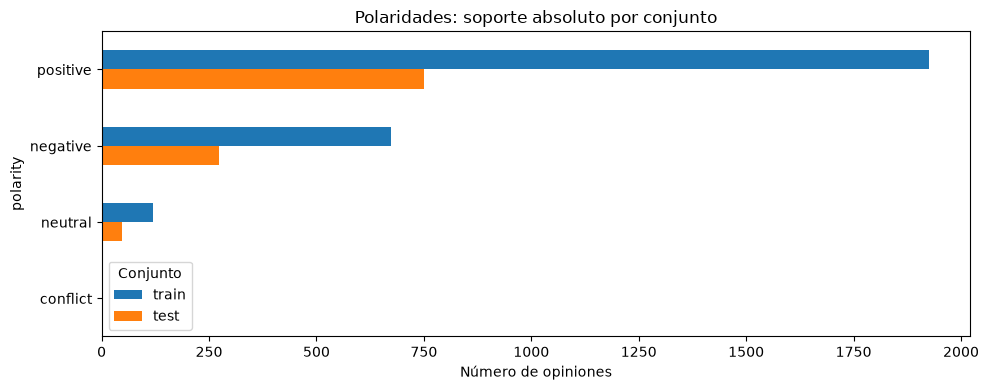

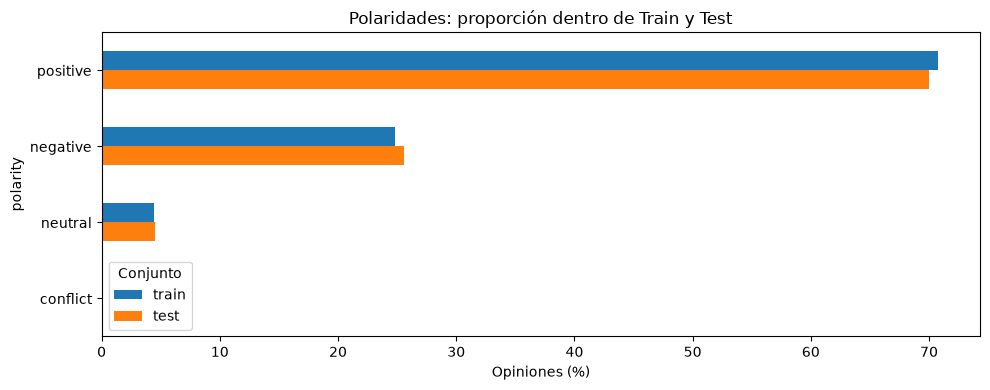

**train:** predomina `positive` (70.77%). La clase menos frecuente es `conflict` (1 opiniones).

**test:** predomina `positive` (69.96%). La clase menos frecuente es `neutral` (48 opiniones).

In [12]:
def distribution(column):
    """Frecuencias por conjunto, sin aprender una transformación del corpus."""
    rows = []
    for split, tables in data.items():
        counts = tables["opinions"][column].fillna("<FALTANTE>").value_counts()
        for value, count in counts.items():
            rows.append({"split": split, column: value, "count": count,
                         "percentage": 100 * count / len(tables["opinions"])})
    return pd.DataFrame(rows)

def compare_bars(table, column, title, percentage=True):
    measure = "percentage" if percentage else "count"
    order = table.groupby(column)["count"].sum().sort_values(ascending=False).index
    pivot = table.pivot(index=column, columns="split", values=measure).reindex(order).fillna(0)
    ax = pivot[["train", "test"]].plot.barh(figsize=(10, max(4, len(order) * .45)))
    ax.invert_yaxis()
    ax.set(title=title, xlabel="Opiniones (%)" if percentage else "Número de opiniones", ylabel=column)
    ax.legend(title="Conjunto")
    plt.tight_layout()
    plt.show()

polarity_distribution = distribution("polarity")
display(polarity_distribution.round(2))
compare_bars(polarity_distribution, "polarity", "Polaridades: soporte absoluto por conjunto", False)
compare_bars(polarity_distribution, "polarity", "Polaridades: proporción dentro de Train y Test")
for split in data:
    counts = polarity_distribution.query("split == @split").sort_values("count", ascending=False)
    major, minor = counts.iloc[0], counts.iloc[-1]
    display(Markdown(f"**{split}:** predomina `{major['polarity']}` ({major['percentage']:.2f}%). "
                     f"La clase menos frecuente es `{minor['polarity']}` ({minor['count']} opiniones)."))

### Interpretación

La frecuencia desigual exige distinguir rendimiento global y por clase en la evaluación futura: un resultado agregado puede ocultar errores en minorías. Se conserva `conflict` cuando aparece; su tratamiento deberá definirse explícitamente antes de modelar. La presencia de varias polaridades en una oración no autoriza a asignarle una sola etiqueta.

**Resultados verificados en los archivos actuales.** train: positive representa 70.77% y neutral 4.41%; test: positive representa 69.96% y neutral 4.48%. Solo Train contiene conflict (1 opinión); Test no permitirá estimar el rendimiento de esa clase de manera separada.

## 7. Categorías de aspectos, entidades y atributos

Se muestran todas las categorías observadas. Los gráficos se ordenan por frecuencia total **solo con fines descriptivos**. Cada opinión aporta una categoría; `entity` y `attribute` se derivan de `ENTITY#ATTRIBUTE` sin alterar `category`.

train: 12 categorías diferentes
test: 12 categorías diferentes


,split,category,count,percentage
12,test,FOOD#QUALITY,291,27.15
13,test,SERVICE#GENERAL,222,20.71
14,test,RESTAURANT#GENERAL,222,20.71
15,test,AMBIENCE#GENERAL,126,11.75
16,test,FOOD#STYLE_OPTIONS,69,6.44
17,test,FOOD#PRICES,41,3.82
18,test,RESTAURANT#PRICES,39,3.64
19,test,LOCATION#GENERAL,18,1.68
20,test,RESTAURANT#MISCELLANEOUS,13,1.21
21,test,DRINKS#STYLE_OPTIONS,11,1.03


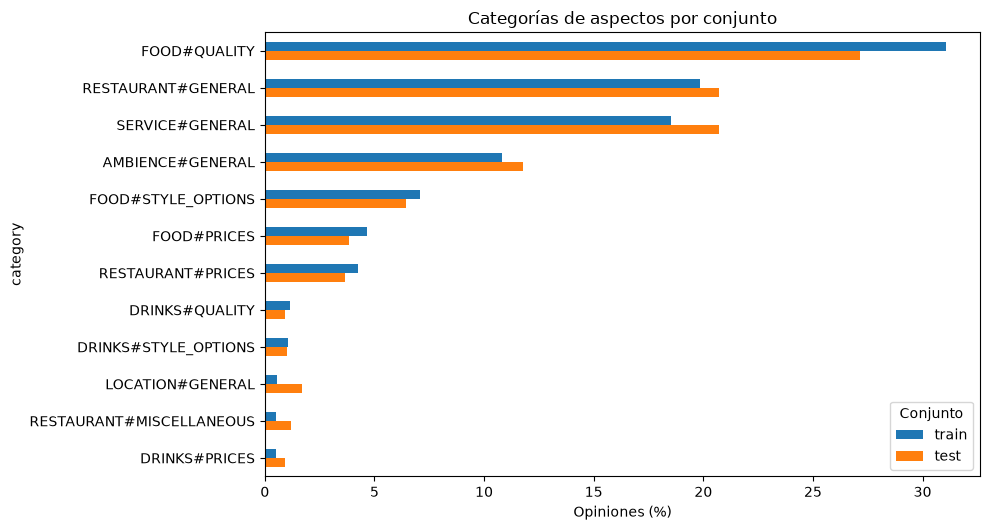

,split,entity,count,percentage
6,test,FOOD,401,37.41
7,test,RESTAURANT,274,25.56
8,test,SERVICE,222,20.71
9,test,AMBIENCE,126,11.75
10,test,DRINKS,31,2.89
11,test,LOCATION,18,1.68
0,train,FOOD,1164,42.79
1,train,RESTAURANT,669,24.60
2,train,SERVICE,504,18.53
3,train,AMBIENCE,294,10.81


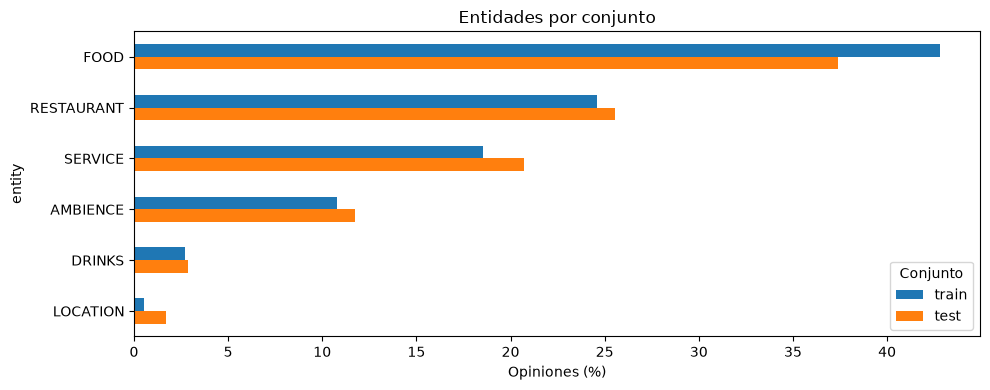

,split,attribute,count,percentage
5,test,GENERAL,588,54.85
6,test,QUALITY,301,28.08
7,test,PRICES,90,8.40
8,test,STYLE_OPTIONS,80,7.46
9,test,MISCELLANEOUS,13,1.21
0,train,GENERAL,1353,49.74
1,train,QUALITY,876,32.21
2,train,PRICES,256,9.41
3,train,STYLE_OPTIONS,221,8.12
4,train,MISCELLANEOUS,14,0.51


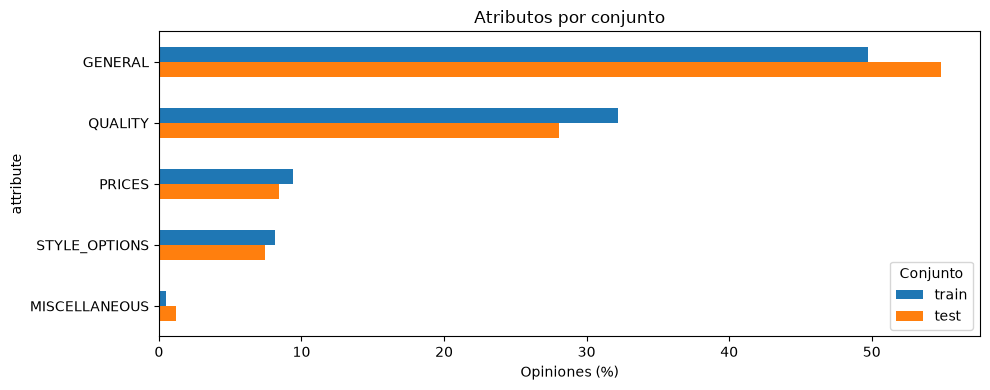

In [13]:
for split, tables in data.items():
    o = tables["opinions"]
    components = o["category"].astype("string").str.split("#", n=1, expand=True)
    o["entity"], o["attribute"] = components[0], components[1]
    print(f"{split}: {o['category'].nunique()} categorías diferentes")
category_distribution = distribution("category")
entity_distribution = distribution("entity")
attribute_distribution = distribution("attribute")
for column, table, title in [
    ("category", category_distribution, "Categorías de aspectos por conjunto"),
    ("entity", entity_distribution, "Entidades por conjunto"),
    ("attribute", attribute_distribution, "Atributos por conjunto"),
]:
    display(table.sort_values(["split", "count"], ascending=[True, False]).round(2))
    compare_bars(table, column, title)

### Interpretación

La concentración en ciertas categorías refleja qué aspectos se comentan más, no cuáles son necesariamente mejores. Descomponer categoría en entidad y atributo permite distinguir el objeto evaluado (por ejemplo comida) de la dimensión evaluada (por ejemplo calidad). Las categorías escasas tendrán menor soporte para estimaciones posteriores.

**Resultados verificados.** train contiene 12 categorías, 6 entidades y 5 atributos; predomina FOOD#QUALITY con 845 opiniones (31.07%); test contiene 12 categorías, 6 entidades y 5 atributos; predomina FOOD#QUALITY con 291 opiniones (27.15%).

### 7.1. Relación entre categoría y polaridad

Se calculan recuentos y porcentajes **dentro de cada categoría**, por separado para Train y Test. Las barras apiladas suman 100% por categoría. Deben leerse junto al soporte de la tabla: porcentajes extremos con muy pocas opiniones no son evidencia sólida.

train: recuentos y porcentajes por categoría (NaN = sin soporte)


polarity,positive,negative,neutral,conflict
category,,,,
FOOD#QUALITY,668,132,45,0
RESTAURANT#GENERAL,420,104,16,0
SERVICE#GENERAL,370,119,15,0
AMBIENCE#GENERAL,188,88,17,1
FOOD#STYLE_OPTIONS,100,83,9,0
FOOD#PRICES,67,56,4,0
RESTAURANT#PRICES,50,52,13,0
DRINKS#QUALITY,25,6,0,0
DRINKS#STYLE_OPTIONS,11,18,0,0


polarity,positive,negative,neutral,conflict
category,,,,
FOOD#QUALITY,79.05,15.62,5.33,0.00
RESTAURANT#GENERAL,77.78,19.26,2.96,0.00
SERVICE#GENERAL,73.41,23.61,2.98,0.00
AMBIENCE#GENERAL,63.95,29.93,5.78,0.34
FOOD#STYLE_OPTIONS,52.08,43.23,4.69,0.00
FOOD#PRICES,52.76,44.09,3.15,0.00
RESTAURANT#PRICES,43.48,45.22,11.30,0.00
DRINKS#QUALITY,80.65,19.35,0.00,0.00
DRINKS#STYLE_OPTIONS,37.93,62.07,0.00,0.00


test: recuentos y porcentajes por categoría (NaN = sin soporte)


polarity,positive,negative,neutral,conflict
category,,,,
FOOD#QUALITY,226,47,18,0
RESTAURANT#GENERAL,172,40,10,0
SERVICE#GENERAL,157,60,5,0
AMBIENCE#GENERAL,77,45,4,0
FOOD#STYLE_OPTIONS,36,29,4,0
FOOD#PRICES,24,16,1,0
RESTAURANT#PRICES,16,19,4,0
DRINKS#QUALITY,9,1,0,0
DRINKS#STYLE_OPTIONS,5,5,1,0


polarity,positive,negative,neutral,conflict
category,,,,
FOOD#QUALITY,77.66,16.15,6.19,0.0
RESTAURANT#GENERAL,77.48,18.02,4.50,0.0
SERVICE#GENERAL,70.72,27.03,2.25,0.0
AMBIENCE#GENERAL,61.11,35.71,3.17,0.0
FOOD#STYLE_OPTIONS,52.17,42.03,5.80,0.0
FOOD#PRICES,58.54,39.02,2.44,0.0
RESTAURANT#PRICES,41.03,48.72,10.26,0.0
DRINKS#QUALITY,90.00,10.00,0.00,0.0
DRINKS#STYLE_OPTIONS,45.45,45.45,9.09,0.0


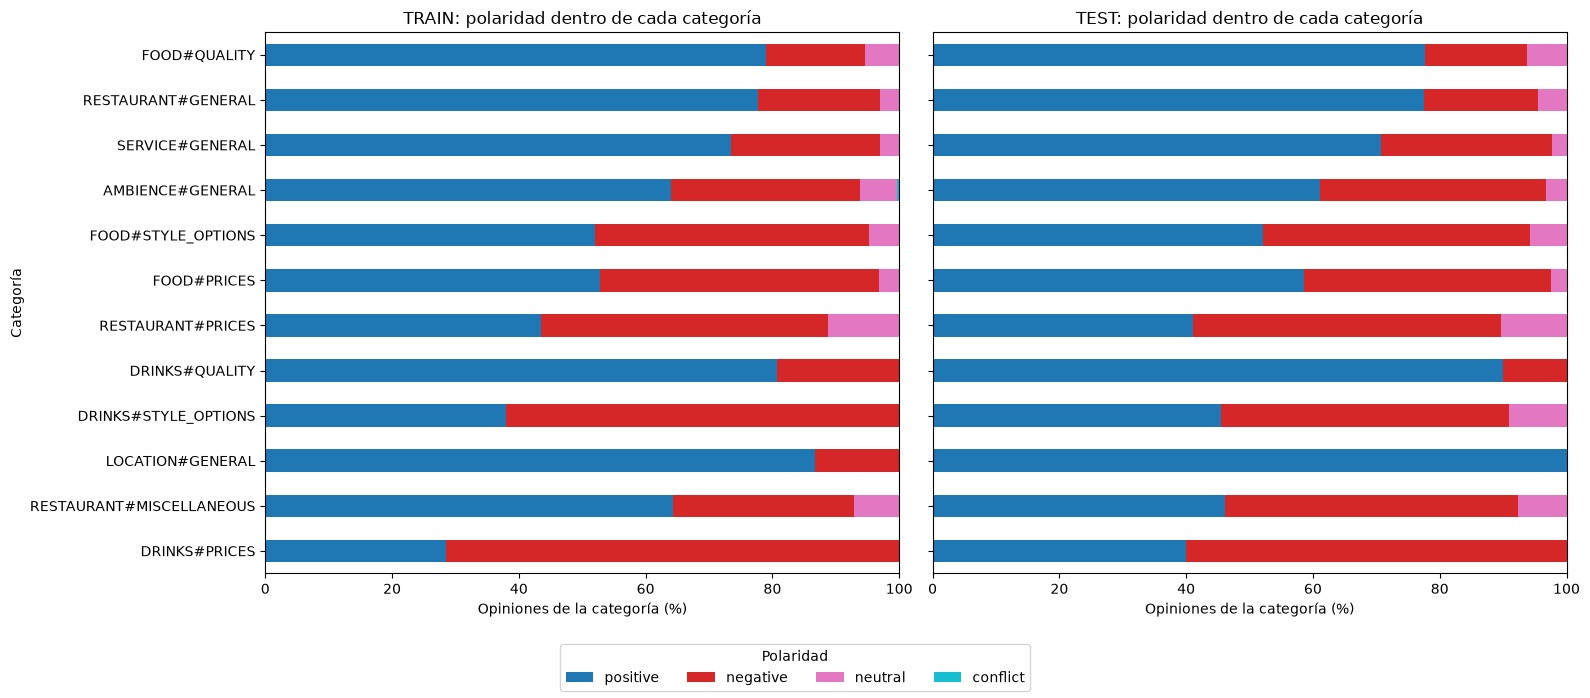

In [14]:
category_polarity = {}
polarity_order = polarity_distribution["polarity"].drop_duplicates().tolist()
category_order = category_distribution.groupby("category")["count"].sum().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (split, tables) in zip(axes, data.items()):
    counts = pd.crosstab(tables["opinions"]["category"], tables["opinions"]["polarity"])
    counts = counts.reindex(index=category_order, columns=polarity_order, fill_value=0)
    percentages = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).mul(100)
    category_polarity[split] = (counts, percentages)
    print(f"{split}: recuentos y porcentajes por categoría (NaN = sin soporte)")
    display(counts, percentages.round(2))
    percentages.fillna(0).plot.barh(stacked=True, ax=ax, colormap="tab10")
    ax.set(title=f"{split.upper()}: polaridad dentro de cada categoría", xlabel="Opiniones de la categoría (%)", ylabel="Categoría", xlim=(0, 100))
    ax.get_legend().remove()
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Polaridad", loc="lower center", ncol=len(labels))
plt.tight_layout(rect=(0, .09, 1, 1))
plt.show()

### Interpretación de la relación categoría–polaridad

En Train, DRINKS#PRICES tiene la mayor proporción negativa (71.43%, 10 de 14 opiniones); en test, DRINKS#PRICES tiene la mayor proporción negativa (60.00%, 6 de 10 opiniones). El soporte reducido limita la generalización de estas proporciones.

## 8. Análisis de los Opinion Targets

`NULL` significa objetivo implícito, no dato perdido. El ranking excluye tanto `NULL` como faltantes reales. Para reunir variantes de escritura, únicamente el ranking usa minúsculas y espacios uniformes; `target` original permanece intacto.

,frecuencia_train
target,
comida,243
servicio,227
restaurante,78
ambiente,67
trato,50
sitio,41
local,40
platos,37
cocina,32


,frecuencia_test
target,
comida,105
servicio,85
restaurante,44
ambiente,22
trato,19
platos,18
carne,16
sitio,15
camareros,14


,explícitos,implícitos_NULL,faltantes_reales,implícitos_%
split,,,,
train,1937,783,0,28.79
test,731,341,0,31.81


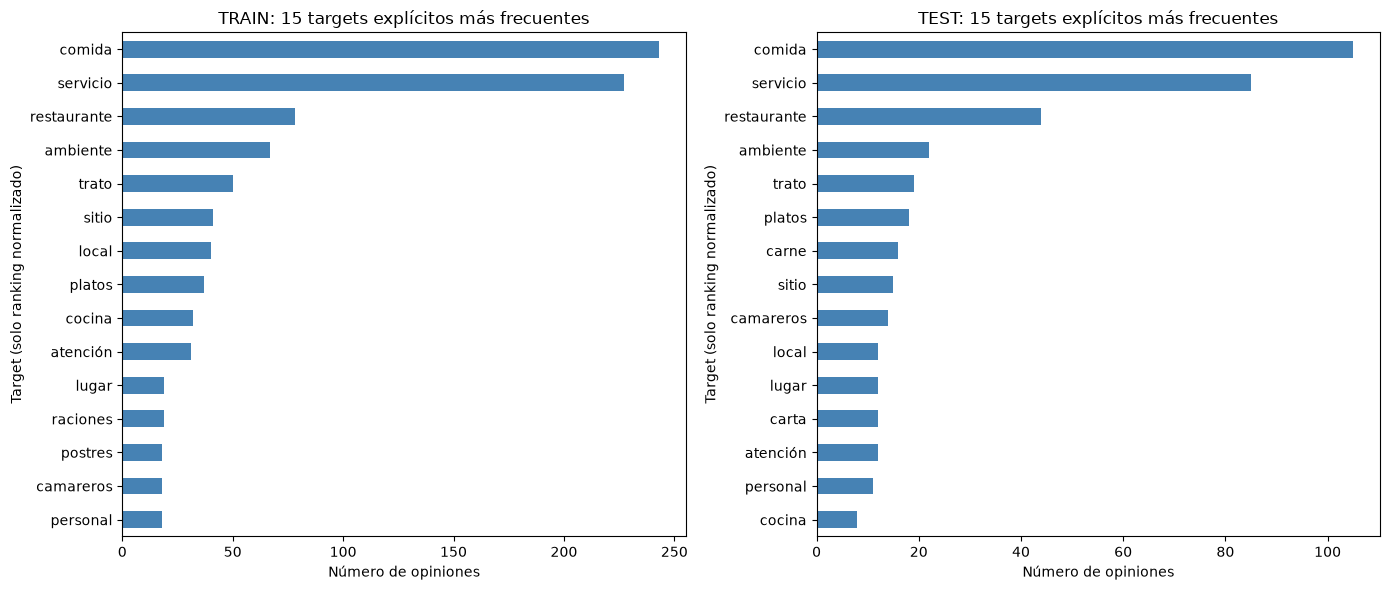

In [15]:
target_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (split, tables) in zip(axes, data.items()):
    target = tables["opinions"]["target"]
    implicit = target.eq("NULL")
    absent = missing_mask(target)
    explicit = ~implicit & ~absent
    target_rows.append({"split": split, "explícitos": explicit.sum(),
        "implícitos_NULL": implicit.sum(), "faltantes_reales": absent.sum(),
        "implícitos_%": 100 * implicit.mean()})
    ranking = target[explicit].str.lower().str.replace(r"\s+", " ", regex=True).str.strip().value_counts().head(15)
    display(ranking.rename(f"frecuencia_{split}").to_frame())
    ranking.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set(title=f"{split.upper()}: 15 targets explícitos más frecuentes", xlabel="Número de opiniones", ylabel="Target (solo ranking normalizado)")
target_summary = pd.DataFrame(target_rows).set_index("split")
display(target_summary.round(2))
plt.tight_layout()
plt.show()

### Interpretación

Los objetivos implícitos requieren interpretar el contexto; no pueden recuperarse buscando una cadena literal en la oración. La frecuencia de un target no indica su polaridad. El ranking cuenta anotaciones, por lo que un mismo término puede contribuir más de una vez cuando recibe distintas opiniones.

**Resultados verificados en los archivos actuales.** Los targets implícitos representan 28.79% en Train y 31.81% en Test. No se encontraron targets realmente faltantes.

## 9. Análisis exploratorio de los textos

Una fila por oración, incluidas las que no tienen opiniones y las `OutOfScope`. Los caracteres se cuentan sobre el texto original. Las palabras se aproximan mediante secuencias alfanuméricas Unicode (`\b\w+\b`); no son los tokens de un futuro Transformer. No se deduplican textos de oraciones distintas.

train


,n_chars,n_words
count,2070.00,2070.00
mean,86.42,15.10
std,86.82,15.65
min,2.00,0.00
25%,34.00,6.00
50%,62.00,11.00
75%,105.75,19.00
max,875.00,160.00


test


,n_chars,n_words
count,881.00,881.00
mean,75.20,13.01
std,72.91,13.10
min,3.00,1.00
25%,30.00,5.00
50%,54.00,9.00
75%,96.00,17.00
max,766.00,139.00


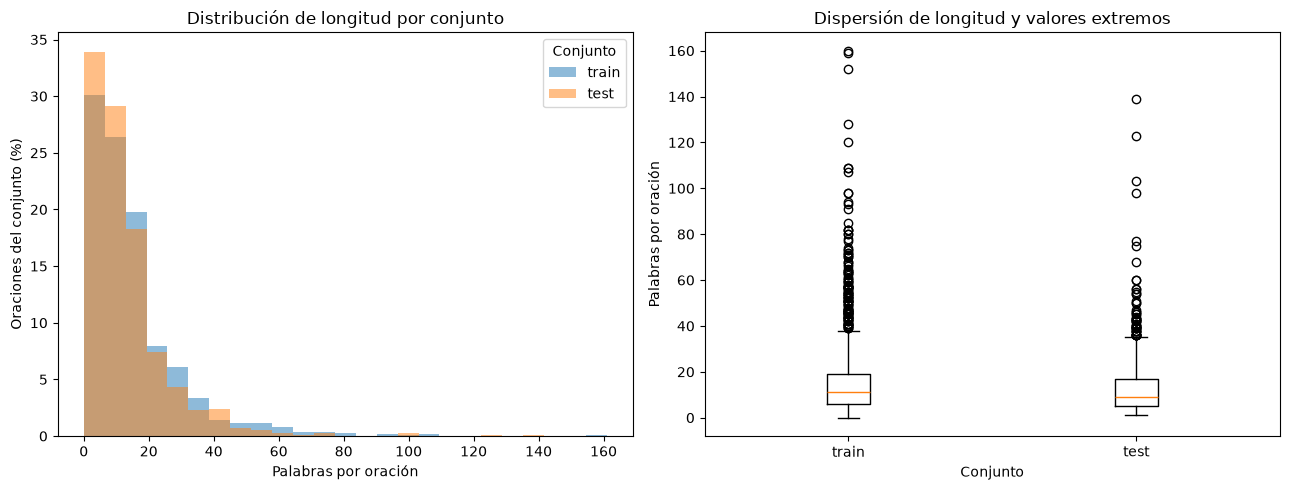

train: tres oraciones más cortas y tres más largas


,sentence_id,text,n_chars,n_words,n_opinions
1928,es_puerto-de-santa-maria-zaragoza_comment-1671:1,[…],4,0,0
14,es_9reinas_18_DanielGonzalez_2014-02-01:3,Volveremos.,11,1,1
35,es_9reinas_38_AdamNash_2013-02-13:0,Fantastico!!!,13,1,1
1581,es_bal-donsera-zaragoza_comment-3636:22,"Seguidamente de advertirnos el cambio, nos pregunta si un vino blanco nos parecía bien para empe...",862,160,3
1943,es_puerto-de-santa-maria-zaragoza_comment-4300:1,"El 21/01/2014Fuimos Mi Pareja Y Yo A CenarEl Trato Muy CorrectoLas Tortillitas ,El Tomate Y Choc...",875,159,9
1938,es_puerto-de-santa-maria-zaragoza_comment-3168:0,hola buenas agradezco a todas las personas que hayan puesto estos comentarios porque esto la ver...,846,152,0


test: tres oraciones más cortas y tres más largas


,sentence_id,text,n_chars,n_words,n_opinions
3,es_9reinas_11_CarlosPerezAlvarez_2014-09-14:0,"Buff,",5,1,0
13,es_9reinas_13_MaraKacic_2014-08-06:1,Imperdible!,11,1,1
160,es_cafe-meccano-gastrobar-zaragoza_comment-3719:17,escasito.,9,1,0
652,es_bal-donsera-zaragoza_comment-1302:1,Yo estuve en marzo y en principio me pareció que las conversaciones de las mesas se oían y moles...,766,139,4
230,es_luis-candelas-zaragoza_comment-3735:0,Un comentario apropiado para el restaurante El Candelas: Es una pena que personas que estamos h...,702,123,8
231,es_luis-candelas-zaragoza_comment-3735:1,"Se me olvidaba, también podemos degustar el mejor chuletón de buey de Navarra que puedas encontr...",587,103,3


,split,umbral_superior_IQR,sobre_umbral,hasta_2_palabras
0,train,38.5,128,204
1,test,35.0,53,91


train: textos que requieren revisión contextual


,sentence_id,text,n_opinions,out_of_scope
486,es_la-scala-zaragoza_comment-4683:0,Escriba aquí su comentario…,0,NaN
489,es_la-scala-zaragoza_comment-4705:0,Escriba aquí su comentario…Todo un descubrimiento.,1,NaN
494,es_la-scala-zaragoza_comment-4739:0,Escriba aquí su comentario…,0,NaN
601,es_luis-candelas-zaragoza_comment-4668:0,"Escriba aquí su comentario:Muy buen restaurante en relación calidad/precio y cantidad, los callo...",4,NaN
602,es_luis-candelas-zaragoza_comment-4726:0,Escriba aquí su comentario…,0,NaN
606,es_luis-candelas-zaragoza_comment-4860:0,Escriba aquí su comentario…Buena relación calidad -precio.,2,NaN
1928,es_puerto-de-santa-maria-zaragoza_comment-1671:1,[…],0,NaN


test: textos que requieren revisión contextual


,sentence_id,text,n_opinions,out_of_scope
140,es_bodega-de-chema-la-zaragoza_comment-4295:0,Escriba aquí su comentario…,0,NaN
244,es_luis-candelas-zaragoza_comment-4254:0,Escriba aquí su comentario…cenamos muy bien.,1,NaN
751,es_matilde-la-zaragoza_comment-4830:0,Escriba aquí su comentario…,0,NaN


,split,sin_tokens_de_palabra,posible_texto_de_formulario
0,train,1,6
1,test,0,3


In [16]:
WORD_PATTERN = re.compile(r"\b\w+\b", flags=re.UNICODE)
length_stats = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
max_words = 0
for split, tables in data.items():
    s = tables["sentences"]
    s["n_chars"] = s["text"].str.len()
    s["n_words"] = s["text"].map(lambda value: len(WORD_PATTERN.findall(value)) if isinstance(value, str) else np.nan)
    length_stats[split] = s[["n_chars", "n_words"]].describe()
    max_words = max(max_words, s["n_words"].max())
    print(split)
    display(length_stats[split].round(2))
bins = np.linspace(0, max_words + 1, 26)
for split, tables in data.items():
    values = tables["sentences"]["n_words"].dropna()
    axes[0].hist(values, bins=bins, weights=np.full(len(values), 100 / len(values)),
                 alpha=.5, label=split)
axes[0].set(title="Distribución de longitud por conjunto", xlabel="Palabras por oración", ylabel="Oraciones del conjunto (%)")
axes[0].legend(title="Conjunto")
axes[1].boxplot([tables["sentences"]["n_words"].dropna() for tables in data.values()], tick_labels=list(data))
axes[1].set(title="Dispersión de longitud y valores extremos", xlabel="Conjunto", ylabel="Palabras por oración")
plt.tight_layout()
plt.show()

extreme_rows = []
for split, tables in data.items():
    s = tables["sentences"]
    q1, q3 = s["n_words"].quantile([.25, .75])
    limit = q3 + 1.5 * (q3 - q1)
    extreme_rows.append({"split": split, "umbral_superior_IQR": limit,
                         "sobre_umbral": s["n_words"].gt(limit).sum(),
                         "hasta_2_palabras": s["n_words"].le(2).sum()})
    print(f"{split}: tres oraciones más cortas y tres más largas")
    display(pd.concat([s.nsmallest(3, "n_words"), s.nlargest(3, "n_words")])[
        ["sentence_id", "text", "n_chars", "n_words", "n_opinions"]])
display(pd.DataFrame(extreme_rows))

# Inspección de textos sin palabras y de una frase de formulario observada.
text_anomalies = []
for split, tables in data.items():
    s = tables["sentences"]
    no_words = s["n_words"].eq(0)
    placeholder = s["text"].str.contains("Escriba aquí su comentario", case=False, regex=False, na=False)
    text_anomalies.append({"split": split, "sin_tokens_de_palabra": no_words.sum(),
                           "posible_texto_de_formulario": placeholder.sum()})
    print(f"{split}: textos que requieren revisión contextual")
    display(s.loc[no_words | placeholder, ["sentence_id", "text", "n_opinions", "out_of_scope"]])
display(pd.DataFrame(text_anomalies))


### Interpretación

El histograma compara proporciones con los mismos intervalos. El boxplot y el criterio de 1,5 veces el rango intercuartílico señalan extremos descriptivos, no errores. Las oraciones muy cortas pueden depender de la reseña para su interpretación; las largas pueden contener varios aspectos. Se conservan todas y no se decide truncamiento a partir de Test.

**Resultados verificados.** train: media 15.10, mediana 11 y máximo 160 palabras; test: media 13.01, mediana 9 y máximo 139 palabras. Se observó una oración sin tokens de palabra y 9 apariciones del texto de formulario «Escriba aquí su comentario». Los casos se muestran arriba y se conservan.

### 9.1. Frecuencias léxicas exploratorias

Se generan rankings **independientes por conjunto**, contando cada oración una vez. Solo para estos conteos se usan minúsculas y secuencias de letras (se excluyen puntuación, dígitos y guiones bajos). No se construye un vocabulario para entrenamiento.

No hay un corpus español de stopwords disponible entre las dependencias utilizadas. Para evitar una descarga o una lista arbitraria extensa, se muestran tanto el ranking sin filtro como un ranking con la lista mínima **`el`, `la`, `de`, `y`**, ejemplos explícitos de la diapositiva 13 de la sesión 2. Es un filtro ilustrativo, **no una lista completa de stopwords españolas**; pueden persistir palabras funcionales. `no`, `ni`, `nunca` y `sin` se preservan. No se atribuyen términos a polaridades de oración porque una oración puede contener opiniones de signos distintos.

train: 20 términos globales sin filtro / con filtro mínimo del curso


,término,frecuencia
0,de,1293
1,y,1219
2,la,1065
3,que,1024
4,el,952
5,en,629
6,muy,537
7,a,515
8,no,506
9,un,500


,término,frecuencia
0,que,1024
1,en,629
2,muy,537
3,a,515
4,no,506
5,un,500
6,con,406
7,es,386
8,lo,350
9,los,338


test: 20 términos globales sin filtro / con filtro mínimo del curso


,término,frecuencia
0,de,479
1,y,473
2,la,378
3,que,324
4,el,315
5,en,238
6,muy,208
7,a,179
8,un,178
9,no,174


,término,frecuencia
0,que,324
1,en,238
2,muy,208
3,a,179
4,un,178
5,no,174
6,con,154
7,es,141
8,los,138
9,lo,133


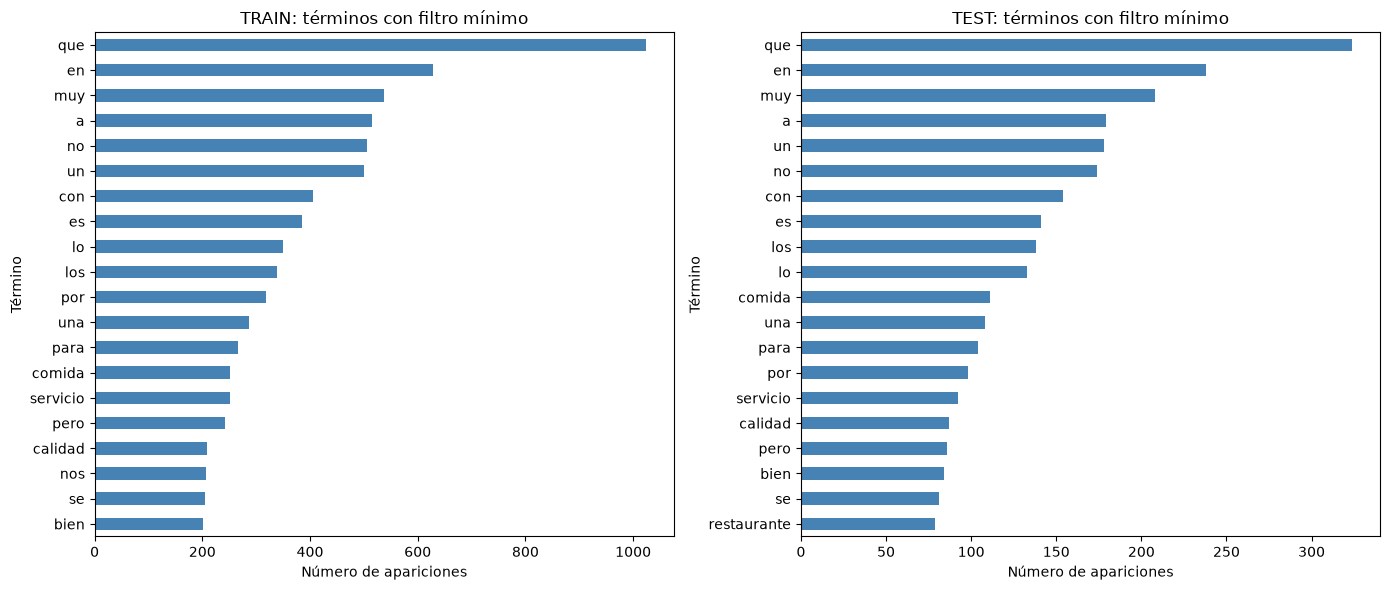

In [17]:
LEXICAL_PATTERN = re.compile(r"[^\W\d_]+", flags=re.UNICODE)
STOPWORDS_COURSE = {"el", "la", "de", "y"}
lexical_counts = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (split, tables) in zip(axes, data.items()):
    counts = Counter(token for text in tables["sentences"]["text"].dropna()
                     for token in LEXICAL_PATTERN.findall(text.lower()))
    filtered = Counter({term: count for term, count in counts.items() if term not in STOPWORDS_COURSE})
    lexical_counts[split] = filtered
    print(f"{split}: 20 términos globales sin filtro / con filtro mínimo del curso")
    display(pd.DataFrame(counts.most_common(20), columns=["término", "frecuencia"]),
            pd.DataFrame(filtered.most_common(20), columns=["término", "frecuencia"]))
    pd.Series(dict(filtered.most_common(20))).sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set(title=f"{split.upper()}: términos con filtro mínimo", xlabel="Número de apariciones", ylabel="Término")
plt.tight_layout()
plt.show()

### Interpretación

Estos recuentos describen el léxico superficial, no el significado ni la relevancia predictiva de los términos. La sesión 3 explica que las frecuencias no capturan por sí solas contexto o sinonimia. El filtro mínimo deja visible esa limitación sin alterar el texto que se utilizará posteriormente.

**Resultados verificados en los archivos actuales.** Los primeros términos con el filtro mínimo son train: que (1024), en (629), muy (537), a (515), no (506); test: que (324), en (238), muy (208), a (179), un (178). La presencia de palabras funcionales evidencia que el filtro es deliberadamente limitado.

## 10. Comparación entre Train y Test

Se compara el soporte de polaridades, categorías, entidades y atributos mediante conjuntos y tablas de porcentajes. Las diferencias se expresan en **puntos porcentuales (Test − Train)**. Ausencia de una categoría no equivale a un porcentaje negativo: se muestra 0 para facilitar la comparación.

In [18]:
coverage_rows = []
for column in ["polarity", "category", "entity", "attribute"]:
    train_values = set(data["train"]["opinions"][column].dropna())
    test_values = set(data["test"]["opinions"][column].dropna())
    coverage_rows.append({"variable": column, "solo_train": sorted(train_values - test_values),
                          "solo_test": sorted(test_values - train_values)})
    percentages = distribution(column).pivot(index=column, columns="split", values="percentage").fillna(0)
    percentages["diferencia_pp_test_train"] = percentages["test"] - percentages["train"]
    print(column)
    display(percentages.round(2))
display(pd.DataFrame(coverage_rows))
comparison = pd.DataFrame({split: {
    "palabras_media": tables["sentences"]["n_words"].mean(),
    "palabras_mediana": tables["sentences"]["n_words"].median(),
    "palabras_Q1": tables["sentences"]["n_words"].quantile(.25),
    "palabras_Q3": tables["sentences"]["n_words"].quantile(.75),
    "targets_implícitos_%": target_summary.loc[split, "implícitos_%"],
} for split, tables in data.items()}).T
display(comparison.round(2))

# Coincidencias exactas de texto entre conjuntos: auditoría, no deduplicación.
shared_texts = set(data["train"]["sentences"]["text"].dropna()) & set(data["test"]["sentences"]["text"].dropna())
print("Textos distintos compartidos literalmente entre Train y Test:", len(shared_texts))
shared_rows = []
for text in sorted(shared_texts):
    shared_rows.append({"text": text, **{split: tables["sentences"]["text"].eq(text).sum()
                                        for split, tables in data.items()}})
display(pd.DataFrame(shared_rows, columns=["text", "train", "test"]))
for name, key in [("reviews", "review_id"), ("sentences", "sentence_id")]:
    overlap = set(data["train"][name][key].dropna()) & set(data["test"][name][key].dropna())
    print(f"{key} compartidos:", len(overlap))

polarity


split,test,train,diferencia_pp_test_train
polarity,,,
conflict,0.00,0.04,-0.04
negative,25.56,24.78,0.78
neutral,4.48,4.41,0.07
positive,69.96,70.77,-0.81


category


split,test,train,diferencia_pp_test_train
category,,,
AMBIENCE#GENERAL,11.75,10.81,0.94
DRINKS#PRICES,0.93,0.51,0.42
DRINKS#QUALITY,0.93,1.14,-0.21
DRINKS#STYLE_OPTIONS,1.03,1.07,-0.04
FOOD#PRICES,3.82,4.67,-0.84
FOOD#QUALITY,27.15,31.07,-3.92
FOOD#STYLE_OPTIONS,6.44,7.06,-0.62
LOCATION#GENERAL,1.68,0.55,1.13
RESTAURANT#GENERAL,20.71,19.85,0.86


entity


...

,variable,solo_train,solo_test
0,polarity,[conflict],[]
1,category,[],[]
2,entity,[],[]
3,attribute,[],[]


,palabras_media,palabras_mediana,palabras_Q1,palabras_Q3,targets_implícitos_%
train,15.10,11.0,6.0,19.0,28.79
test,13.01,9.0,5.0,17.0,31.81


Textos distintos compartidos literalmente entre Train y Test: 15


,text,train,test
0,Comimos muy bien.,1,1
1,El servicio fue perfecto.,1,1
2,Escriba aquí su comentario…,2,1
3,Gracias.,1,2
4,Lo recomiendo.,4,1
5,Muy bien.,2,2
6,Muy recomendable,2,2
7,Muy recomendable.,6,2
8,Recomendable.,1,4
9,Repetiremos seguro.,1,1


review_id compartidos: 0
sentence_id compartidos: 0


### Interpretación

La comparación describe diferencias de composición; no demuestra que ambos conjuntos provengan de distribuciones idénticas. Las coincidencias literales se inspeccionan porque podrían afectar la independencia, aunque frases cortas comunes no prueban por sí solas fuga de datos. Se mantiene la partición oficial. Una futura validación deberá organizarse dentro de Train, preferiblemente por reseña para evitar repartir sus oraciones entre entrenamiento y validación. Test Gold no debe usarse para ajustar modelos, vocabularios ni hiperparámetros.

**Resultados verificados en los archivos actuales.** Ambos conjuntos contienen las mismas 12 categorías. La única polaridad exclusiva es conflict, en Train. Test tiene textos más cortos en promedio (13.01 frente a 15.10 palabras) y 3.02 puntos porcentuales más de targets implícitos. Hay 15 textos distintos compartidos, pero ningún review_id ni sentence_id compartido.

## 11. Normalización y preprocesamiento

Se crea **`text_normalized`** mediante minúsculas y normalización de espacios, de forma determinista y sin parámetros aprendidos. **`text` permanece intacto**, tal como fue leído por el parser XML.

La sesión 2 presenta varias operaciones posibles; se adaptan a ABSA:

- Se conservan puntuación, tildes, números y negaciones: pueden aportar significado, intensidad o información sobre precios.
- No se eliminan stopwords del texto normalizado, ni se aplica stemming o lematización. Estas operaciones pueden borrar señales y la lematización contextual requeriría recursos lingüísticos adicionales (sesión 2, diapositivas 14–15).
- La tokenización sencilla anterior sirve para describir longitudes y frecuencias, no reemplaza un futuro tokenizador de modelo.
- Para Transformers, se decidirá después qué versión de texto acepta el modelo; la copia en minúsculas no obliga a usarla. La sesión 4 enfatiza el contexto.
- `from` y `to` siguen referidos exclusivamente a **`text`**. No se recalculan sobre la versión normalizada.

In [19]:
def normalize_text(text):
    return re.sub(r"\s+", " ", text).strip().lower() if isinstance(text, str) else text

assert normalize_text("  No   fue BUENO.  ") == "no fue bueno."
assert normalize_text("¡Sí, costó 20 €!") == "¡sí, costó 20 €!"
normalization_rows = []
for split, tables in data.items():
    for name in ["sentences", "opinions"]:
        frame = tables[name]
        original = frame["text"].copy(deep=True)
        frame["text_normalized"] = frame["text"].map(normalize_text)
        assert frame["text"].equals(original)
    s = tables["sentences"]
    changed = s["text"].ne(s["text_normalized"]) & s["text"].notna()
    normalization_rows.append({"split": split, "oraciones_modificadas_en_copia": changed.sum(),
                               "porcentaje": 100 * changed.mean()})
    print(split)
    display(s.loc[changed, ["sentence_id", "text", "text_normalized"]].head(5))
display(pd.DataFrame(normalization_rows).round(2))

# Variables separadas listas para preparación posterior; no se entrena nada.
train_sentences, test_sentences = data["train"]["sentences"], data["test"]["sentences"]
train_opinions, test_opinions = data["train"]["opinions"], data["test"]["opinions"]

train


,sentence_id,text,text_normalized
0,es_9reinas_10_JordiCollGranell_2014-09-21:0,Nos sentimos muy a gusto.,nos sentimos muy a gusto.
1,es_9reinas_10_JordiCollGranell_2014-09-21:1,"Buen servicio, ambiente Acogedor y tranquilo, comida bien.","buen servicio, ambiente acogedor y tranquilo, comida bien."
2,es_9reinas_10_JordiCollGranell_2014-09-21:2,Muy recomendable,muy recomendable
3,es_9reinas_12_RomanAlimena_2014-09-04:0,"La atencion es muy buena, los camareros estan muy pendientes de uno todo el tiempo.","la atencion es muy buena, los camareros estan muy pendientes de uno todo el tiempo."
4,es_9reinas_12_RomanAlimena_2014-09-04:1,"Y la comida espectacular, por eso lo bueno se paga...","y la comida espectacular, por eso lo bueno se paga..."


test


,sentence_id,text,text_normalized
0,es_9reinas_0_MonicaNavarroOlive_2015-04-19:0,La comida estuvo muy sabrosa.,la comida estuvo muy sabrosa.
1,es_9reinas_0_MonicaNavarroOlive_2015-04-19:1,"Quien sea amante de la carne tiene una carta bastante amplia para elegir., aunque ayer no tenía...","quien sea amante de la carne tiene una carta bastante amplia para elegir., aunque ayer no tenían..."
2,es_9reinas_0_MonicaNavarroOlive_2015-04-19:2,Lo único que nos sorprendió es que nos sirvieran los entrantes y los platos principales a la vez.,lo único que nos sorprendió es que nos sirvieran los entrantes y los platos principales a la vez.
3,es_9reinas_11_CarlosPerezAlvarez_2014-09-14:0,"Buff,","buff,"
4,es_9reinas_11_CarlosPerezAlvarez_2014-09-14:1,No se donde empezar!,no se donde empezar!


,split,oraciones_modificadas_en_copia,porcentaje
0,train,1946,94.01
1,test,823,93.42


## Principales hallazgos del análisis exploratorio

La celda siguiente calcula el resumen desde las tablas anteriores para que las cifras se actualicen al ejecutar el cuaderno. Son hallazgos exploratorios, no conclusiones sobre modelos.

In [20]:
findings = []
for split, tables in data.items():
    o, s = tables["opinions"], tables["sentences"]
    polarities = o["polarity"].value_counts()
    categories = o["category"].value_counts()
    polarity_text = "; ".join(f"{key}: {count} ({100 * count / len(o):.2f}%)" for key, count in polarities.items())
    top_categories = ", ".join(f"{key} ({count}; {100 * count / len(o):.2f}%)" for key, count in categories.head(3).items())
    span_errors = (~span_checks[split]["span_status"].isin(["coincide", "implícito"])).sum()
    required_missing = missing.loc[(missing["split"] == split) & missing["obligatorio"], ["ausente", "vacío_o_espacios"]].sum().sum()
    findings.append(f"- **{split.upper()}:** {len(tables['reviews'])} reseñas, {len(s)} oraciones y {len(o)} opiniones. "
        f"Polaridades: {polarity_text}. Predominan {top_categories}. "
        f"Targets implícitos: {target_summary.loc[split, 'implícitos_NULL']} ({target_summary.loc[split, 'implícitos_%']:.2f}%). "
        f"Longitud: media {s['n_words'].mean():.2f}, mediana {s['n_words'].median():.0f}, "
        f"rango {s['n_words'].min()}–{s['n_words'].max()} palabras. "
        f"Sin opiniones: {quality.loc[split, 'sin_opiniones']:.0f}; OutOfScope: {quality.loc[split, 'OutOfScope_TRUE']:.0f} "
        f"({quality.loc[split, 'OutOfScope_%']:.2f}%). "
        f"Campos obligatorios faltantes/vacíos: {required_missing}; incidencias de offsets explícitos: {span_errors}.")
exact_duplicates = duplicates.loc[duplicates["revisión"].eq("anotación exacta con offsets")]
findings.append("- **Anotaciones repetidas:** " + "; ".join(
    f"{row['split']}: {row['filas_repetidas_adicionales']} filas adicionales idénticas"
    for _, row in exact_duplicates.iterrows()) + ". Se conservan para revisión del origen.")
findings.append("- **Textos a revisar:** " + "; ".join(
    f"{row['split']}: {row['sin_tokens_de_palabra']} sin tokens de palabra y "
    f"{row['posible_texto_de_formulario']} posibles textos de formulario" for row in text_anomalies)
    + ". No se eliminan automáticamente.")
findings.append(f"- **Comparabilidad:** {len(shared_texts)} textos distintos coinciden literalmente entre Train y Test. "
                "Las diferencias de cobertura de etiquetas se detallan en la sección 10.")
display(Markdown("\n".join(findings)))

- **TRAIN:** 627 reseñas, 2070 oraciones y 2720 opiniones. Polaridades: positive: 1925 (70.77%); negative: 674 (24.78%); neutral: 120 (4.41%); conflict: 1 (0.04%). Predominan FOOD#QUALITY (845; 31.07%), RESTAURANT#GENERAL (540; 19.85%), SERVICE#GENERAL (504; 18.53%). Targets implícitos: 783 (28.79%). Longitud: media 15.10, mediana 11, rango 0–160 palabras. Sin opiniones: 444; OutOfScope: 124 (5.99%). Campos obligatorios faltantes/vacíos: 0; incidencias de offsets explícitos: 0.
- **TEST:** 268 reseñas, 881 oraciones y 1072 opiniones. Polaridades: positive: 750 (69.96%); negative: 274 (25.56%); neutral: 48 (4.48%). Predominan FOOD#QUALITY (291; 27.15%), SERVICE#GENERAL (222; 20.71%), RESTAURANT#GENERAL (222; 20.71%). Targets implícitos: 341 (31.81%). Longitud: media 13.01, mediana 9, rango 1–139 palabras. Sin opiniones: 204; OutOfScope: 31 (3.52%). Campos obligatorios faltantes/vacíos: 0; incidencias de offsets explícitos: 0.
- **Anotaciones repetidas:** train: 6 filas adicionales idénticas; test: 5 filas adicionales idénticas. Se conservan para revisión del origen.
- **Textos a revisar:** train: 1 sin tokens de palabra y 6 posibles textos de formulario; test: 0 sin tokens de palabra y 3 posibles textos de formulario. No se eliminan automáticamente.
- **Comparabilidad:** 15 textos distintos coinciden literalmente entre Train y Test. Las diferencias de cobertura de etiquetas se detallan en la sección 10.

### Consideraciones para la etapa posterior

El desbalance de clases y categorías obliga a interpretar las futuras métricas junto con el soporte por clase. Los objetivos implícitos y las oraciones con múltiples aspectos requieren mantener la unidad de opinión. Antes de modelar se deberá acordar el tratamiento de `conflict`, de `OutOfScope` y de las incidencias de anotación; este EDA no los descarta. La normalización conserva las negaciones y el original para permitir decisiones posteriores sin pérdida de información.

### Verificación de requisitos del enunciado y de la teoría

| Requisito | Evidencia en el cuaderno | Sustento local |
|---|---|---|
| Carga de datos semiestructurados | Secciones 1–3: XML, parser y trazabilidad | Enunciado, primer hito; sesión 1, diap. 3–6 y 17 |
| Inspección y calidad | Secciones 2–5: tamaños, tipos, faltantes, duplicados y offsets | Sesión 1, diap. 16–18 |
| Preprocesamiento / normalización | Secciones 9.1 y 11: tokens exploratorios y copia normalizada | Sesión 2, diap. 10–16, adaptadas al contexto de ABSA |
| Visualización | Secciones 6–10: clases, aspectos, targets y textos | Enunciado; sesión 1, diap. 16 y 18 |
| Separación de datos | Tablas por split; comparaciones descriptivas sin ajuste | Sesión 1, diap. 21 |

La propuesta y experimentación de modelos, publicación de resultados y conclusiones generales del proyecto quedan fuera del alcance de este apartado.

**Validación técnica realizada:** todas las celdas de código se ejecutaron en orden en un proceso IPython con las versiones mostradas al inicio; tablas y nueve figuras quedan guardadas. El entorno de revisión impide abrir los puertos de un kernel Jupyter externo, por lo que se usó ejecución IPython en el mismo proceso. Las comprobaciones de conteos, parser, normalización e integridad pasaron.

In [21]:
# Integridad final: archivos sin cambios, tablas completas y texto original conservado.
for split, path in FILES.items():
    assert hashlib.sha256(path.read_bytes()).hexdigest() == hashes_before[split]
    original_sentences = roots[split].findall(".//sentence")
    assert data[split]["sentences"]["text"].tolist() == [node.findtext("text") for node in original_sentences]
    assert len(data[split]["opinions"]) == len(roots[split].findall(".//Opinion"))
    assert data[split]["opinions"]["split"].eq(split).all()
print("Verificación correcta: XML intactos, registros preservados y Train/Test identificados.")

Verificación correcta: XML intactos, registros preservados y Train/Test identificados.


# 4. Propuesta de Modelización

Se propone comparar empíricamente métodos léxicos tradicionales y un Transformer para español, sin presuponer cuál será superior. El **núcleo principal será la clasificación de polaridad por aspecto**, seguido de la identificación de categorías; la extracción de targets será una extensión condicionada al tiempo y recursos del Trabajo Final. Esta sección es metodológica: no ejecuta particiones, vectorizadores, entrenamiento ni evaluación predictiva.

El enunciado `CC219-TP-TF-Enunciado-2026-02.docx`, **primer hito → Propuesta de Modelización**, solicita seleccionar y proponer algoritmos para resolver las preguntas de clasificación/predicción. Se mantienen las tres preguntas del proyecto:

1. **Categoría:** ¿Es posible identificar automáticamente la categoría de aspecto sobre la cual se expresa una opinión en una reseña de restaurante?
2. **Opinion Target Expression:** ¿Es posible identificar automáticamente la expresión textual que representa el objetivo de una opinión dentro de una reseña?
3. **Polaridad:** ¿Es posible clasificar automáticamente la polaridad del sentimiento expresado respecto de un aspecto determinado?

### Fundamento en el curso y el EDA

La sesión 1 (diap. 21–26) fundamenta separación de datos, comparación con baselines, evaluación e interpretabilidad; la diapositiva 24 recomienda expresamente **TF-IDF + Logistic Regression**. La sesión 2 (diap. 9–18 y 29–34) desarrolla extracción de entidades, preprocesamiento, TF-IDF y clasificación supervisada. La sesión 3 (diap. 12–22) diferencia representaciones léxicas y semánticas. La sesión 4 (diap. 4, 9–13 y 23–29) fundamenta contexto, transferencia y adaptación de modelos preentrenados. La semana 6 (diap. 5–9) refuerza las limitaciones léxicas ante sinonimia y negación. Las diapositivas no prescriben BETO ni desarrollan CRF; la elección concreta del checkpoint y los detalles de implementación se complementan con documentación primaria citada.

Los siguientes datos proceden del EDA ejecutado, no de experimentos predictivos:

| Evidencia | Implicación para la propuesta |
|---|---|
| Train: 627 reseñas, 2.070 oraciones y 2.720 opiniones; Test: 268, 881 y 1.072 | Agrupar por reseña; evitar tratar filas de opinión como observaciones independientes para la partición |
| `positive`: 70,77% en Train; `neutral`: 4,41% | Utilizar Macro F1 y métricas por clase, además de Accuracy |
| 12 categorías; `FOOD#QUALITY` reúne 845 opiniones de Train, frente a 14 de `DRINKS#PRICES` | Considerar soporte desigual y evitar conclusiones fuertes sobre categorías escasas |
| Una oración puede contener varias categorías y polaridades | Categorías multietiqueta por oración; sentimiento condicionado al aspecto por opinión |
| `NULL`: 783 opiniones en Train (28,79%) y 341 en Test (31,81%) | Los targets implícitos no tienen un span que pueda etiquetarse con BIO |
| Una opinión `conflict` en Train y ninguna en Test | Acordar explícitamente el alcance de las etiquetas antes de entrenar |
| 6 y 5 anotaciones adicionales exactamente repetidas; 15 textos distintos compartidos entre conjuntos | Conservar trazabilidad y documentar limitaciones; no deduplicar ni alterar Test automáticamente |

Los porcentajes y longitudes de Test ya fueron inspeccionados descriptivamente en el EDA. En adelante se reservará su rendimiento para la evaluación final; no se afirmará que es un conjunto completamente desconocido en términos descriptivos.

## 4.1. Selección y Justificación de Algoritmos

### Unidad de análisis y alcance por pregunta

**Tarea A — Aspect Category Classification (segunda prioridad).** Se propone una instancia por **oración**, con el conjunto de categorías distintas de sus opiniones como salida. Es **clasificación multietiqueta**: una oración puede pertenecer a `FOOD#QUALITY` y `SERVICE#GENERAL` simultáneamente. Los modelos clásicos se adaptarán mediante *One-vs-Rest*; BETO utilizará salidas sigmoid independientes por categoría, no una softmax que obligue a elegir solo una. La entrada será únicamente el texto, sin categoría ni target gold. Las anotaciones repetidas de una categoría se representarán como una sola presencia en el vector de etiquetas, sin borrar filas del EDA. Se incluirán las oraciones en alcance sin opiniones con un conjunto vacío de categorías. No se predice cuántas opiniones hay ni se vincula cada categoría con un span.

No se propone duplicar una misma oración como ejemplos multiclase con categorías incompatibles sin aportar un objetivo que distinga cada instancia. La formulación multietiqueta responde a la estructura real y evita depender de OTE para esta pregunta.

**Tarea C — Aspect Sentiment Classification (comparación principal).** Se propone una instancia por **opinión**, con entrada `oración + categoría + target`, y salida de polaridad. Para targets explícitos también se conservará su posición para distinguir apariciones repetidas; para implícitos se incluirá un indicador de objetivo implícito. Así, en «La comida fue excelente pero el servicio fue terrible», el modelo recibirá información distinta para comida/`FOOD#QUALITY` y servicio/`SERVICE#GENERAL`.

En el experimento principal, categoría y target serán **anotaciones proporcionadas** a todos los modelos por igual. Esto mide sentimiento *condicionado a un aspecto conocido*, no ABSA integral. Su uso no es fuga de la etiqueta de sentimiento dentro de ese protocolo, pero sí una condición de entrada que deberá estar disponible al aplicar el sistema. Si después se utilizan categorías o targets predichos, se evaluará esa cadena por separado, con propagación de errores y sin mezclar sus métricas con las de entradas gold. `review_id`, `sentence_id` y la polaridad gold nunca serán características predictoras.

**Tarea B — Opinion Target Extraction (extensión).** Se plantea una secuencia por oración con etiquetas por token. No es clasificación convencional de documentos. Se preserva la pregunta, pero su implementación no condicionará las dos comparaciones principales. Si no se implementa en el Trabajo Final, se declarará que esta pregunta queda sin respuesta experimental.

### 4.1.1. Logistic Regression

Se propone **TF-IDF + Logistic Regression** como primera línea base: encaja con vectores dispersos de alta dimensionalidad, tiene implementación relativamente sencilla y permite inspeccionar coeficientes y probabilidades estimadas. Estas probabilidades no se asumirán perfectamente calibradas. Para sentimiento se utilizará clasificación multiclase; para categorías, clasificadores binarios One-vs-Rest. La elección sigue la sesión 1, diap. 24, y la compatibilidad de la implementación con entradas dispersas está documentada en [LogisticRegression — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

### 4.1.2. Linear SVM

Se propone **TF-IDF + Linear SVM**, mediante `LinearSVC`, como segunda línea base. Los separadores lineales son apropiados para comparar métodos en espacios léxicos de muchas dimensiones; no se añaden kernels complejos. LR y SVM recibirán exactamente la misma matriz de características en cada configuración de representación, de modo que su contraste examine el algoritmo. SVM entrega márgenes de decisión, no probabilidades por defecto; los umbrales multietiqueta se ajustarán solo con Validation. Se incorpora como comparador clásico solicitado para el proyecto, sin atribuir su desarrollo a diapositivas que no lo explican. Véase [LinearSVC — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html).

### 4.1.3. Transformer preentrenado para español

Se propone **BETO, `dccuchile/bert-base-spanish-wwm-cased`**, como único Transformer. Su ficha de los autores lo identifica como BERT preentrenado en español, de tamaño similar a BERT-Base y con variante que conserva mayúsculas. Se adaptará con una cabeza para cada tarea, partiendo del mismo checkpoint preentrenado; no se propone entrenamiento desde cero. [Ficha oficial de BETO](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased).

La elección concreta es del proyecto, no una recomendación nominal de las diapositivas. Su justificación es el idioma del corpus y la posibilidad de relacionar contexto y aspecto. La sesión 4 sustenta transferencia, ajuste fino y congelamiento de capas. Se plantea una adaptación supervisada acotada, empezando por sentimiento. Antes de ejecutarla se verificará disponibilidad de GPU, memoria y tiempo; no se presupone que el equipo actual permita fine-tuning completo. Si fuera necesario, se evaluará congelar el encoder y entrenar la cabeza, identificando esa variante en el informe. No se añadirán otros Transformers por defecto.

### 4.1.4. Estrategia para Opinion Target Extraction

Se propone adaptar el mismo checkpoint BETO a **token classification con BIO**: `B-ASP` inicia un target explícito, `I-ASP` continúa el fragmento y `O` identifica el resto. La cabeza y el objetivo de entrenamiento serán diferentes de los clasificadores anteriores. No se aplicará TF-IDF + LR/SVM de documentos para localizar spans. No se añade CRF: no se encontró sustento específico en los materiales y ampliaría el alcance.

`target="NULL"` se mantendrá como objetivo implícito. No se inventará un span en la posición cero ni una palabra «NULL» dentro de la oración. Una oración con opiniones implícitas y explícitas conservará sus spans explícitos; una con solo implícitas tendrá etiquetas `O` para extracción explícita. OTE no resolverá la detección de aspectos implícitos ni la vinculación target–categoría. La evaluación de estos objetivos requeriría una extensión distinta.

### 4.1.5. Comparación propuesta y decisiones sobre anotaciones

| Tarea | Modelo propuesto | Representación / salida | Objetivo |
|---|---|---|---|
| Categorías por oración | Logistic Regression One-vs-Rest | TF-IDF → conjunto de categorías | Baseline léxico |
| Categorías por oración | Linear SVM One-vs-Rest | Misma TF-IDF → conjunto de categorías | Segundo baseline |
| Categorías por oración | BETO para clasificación multietiqueta | Tokenización propia → salidas independientes | Comparación contextual |
| Polaridad por opinión | Logistic Regression | TF-IDF condicionado al aspecto → polaridad | Baseline principal |
| Polaridad por opinión | Linear SVM | Misma representación condicionada → polaridad | Segundo baseline principal |
| Polaridad por opinión | BETO para clasificación | Oración y aspecto → polaridad | Comparación contextual principal |
| Target explícito por oración | BETO para token classification | Subtokens alineados → BIO → spans | Extensión experimental |

El objetivo será **comparar empíricamente**, no demostrar superioridad de Transformers. La comparación LR–SVM controlará la representación. El contraste con BETO comparará sistemas léxicos y contextuales completos: también cambiarán arquitectura, preentrenamiento y optimización, por lo que no aislará causalmente solo el efecto de los embeddings. Se registrarán tiempo, recursos y complejidad junto al rendimiento.

**Protocolo propuesto sobre anotaciones, a ratificar antes del Trabajo Final:**

- **`conflict`:** se propone que el núcleo de sentimiento tenga tres clases (`positive`, `negative`, `neutral`) y reservar la única opinión `conflict` para revisión cualitativa, fuera de su entrenamiento y puntuación. No se equiparará a `neutral`. Un solo ejemplo no permite sostener aprendizaje y validación independientes de una cuarta clase. Se documentará expresamente esta restricción y su soporte excluido; no se afirmará reproducción íntegra del protocolo oficial SemEval. La oración seguirá disponible para categorías y OTE. En este apartado no se filtra ningún registro.
- **`OutOfScope`:** se propone excluir esas oraciones de las vistas supervisadas por tarea, conservándolas en el EDA y registrando el filtro común. Las oraciones en alcance sin opiniones sí servirán como ejemplos sin categorías y sin spans; no como ejemplos de sentimiento neutral.
- **Repeticiones y ruido:** antes de entrenar se revisarán las anotaciones idénticas y los textos de formulario de Train. La vista inicial de sentimiento mantendrá las anotaciones y señalará la posible sobreponderación; cualquier política posterior se documentará y aplicará por igual a los modelos. Test Gold no se corregirá ni depurará a partir de sus resultados.

**Interpretabilidad posterior.** Conforme al enunciado y a la sesión 1, diap. 26, se propone inspeccionar coeficientes de LR para identificar términos asociados a cada clase; no se interpretarán como relaciones causales. Como extensión opcional para BETO, se considerará **LIME**, manteniendo fijo el aspecto al perturbar el contexto y examinando pocas instancias de Validation. Se verificará compatibilidad, coste y estabilidad antes de adoptarlo. No se implementa XAI ni se añaden varias técnicas de explicación en esta propuesta.

## 4.2. Estrategia de Representación / Vectorización de Datos

### 4.2.1. TF-IDF y normalización moderada

TF-IDF representará los documentos mediante vectores dispersos: TF refleja frecuencia dentro del documento e IDF reduce el peso de términos extendidos por el corpus de ajuste. Esto corresponde a la sesión 2, diap. 17–28. Se utilizará la copia `text_normalized` del EDA, conservando siempre `text` original. Se mantendrán minúsculas y espacios uniformes para el enfoque clásico, sin eliminar tildes, negaciones (`no`, `nunca`, `sin`) ni stopwords de manera automática. No se aplicará stemming o lematización por costumbre.

El tokenizador de TF-IDF deberá documentarse: aunque el texto conserve puntuación, un tokenizador de palabras puede omitirla. Se propondrá conservar signos expresivos como tokens cuando se evalúe su aporte en Validation; no se asumirá que el filtro exploratorio de cuatro stopwords del EDA es un preprocesamiento óptimo. Las decisiones serán idénticas para LR y SVM.

**Categorías:** TF-IDF de la oración → vector multietiqueta. El vocabulario e IDF se ajustarán sobre las oraciones elegibles de Training interno, una vez por elemento XML, sin multiplicarlas por sus opiniones.

**Sentimiento:** se proporcionará oración, categoría y target. Concatenar sin más el nombre de categoría con una bolsa de palabras solo aporta efectos aditivos y puede ser insuficiente para asociar cada valoración a su aspecto. Por ello se propone una representación dispersa compartida por LR y SVM que combine:

- TF-IDF del contexto completo;
- información de categoría y target en campos separados, con indicador de implícito;
- interacciones **categoría × términos TF-IDF** (una copia de los términos en el bloque de la categoría correspondiente), para permitir pesos léxicos distintos según el aspecto;
- para un target explícito, TF-IDF de su contexto local, delimitado usando sus offsets. El tamaño de esa ventana se decidirá solo con Train/Validation; para `NULL` se conservará el contexto completo y el indicador de implícito.

Esta adaptación es una decisión del proyecto para condicionar el baseline al aspecto, no una técnica presentada literalmente en las diapositivas. Las interacciones continúan siendo características dispersas para clasificadores lineales. Cada vectorizador/encoder se ajustará solo con Training interno. Para IDF del texto completo se contará cada oración interna una sola vez; después su vector se reutilizará en las instancias de opinión. La preparación de campos no tendrá acceso a la polaridad.

### 4.2.2. Unigramas y bigramas

Se propone contrastar unigramas con unigramas + bigramas para expresiones como «muy bueno», «no volvería», «mala atención» y «muy caro». Los bigramas incorporan contexto local, pero no resuelven dependencias largas. Son una extensión acotada del TF-IDF del curso, motivada por la negación descrita en la semana 6, diap. 9, y por el token `no` observado en el EDA; no se afirma que las diapositivas desarrollen específicamente su implementación. Se documentará su construcción mediante [TfidfVectorizer — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

`ngram_range`, `min_df`, `max_features` y `sublinear_tf`, junto a la regularización de LR/SVM, se explorarán mediante un conjunto pequeño de configuraciones en Validation. No se fijan valores óptimos ni búsquedas extensas antes de los experimentos.

### 4.2.3. Representación contextual mediante Transformer

BETO **no usará TF-IDF**. Se empleará el tokenizador correspondiente a `dccuchile/bert-base-spanish-wwm-cased`, sobre `text` original, preservando mayúsculas, puntuación, tildes y negaciones. El vocabulario preentrenado se reutilizará; no se aprenderá otro con Train + Test.

Para categorías, la entrada será la oración. Para sentimiento, se propone un par de secuencias: **oración** y **descripción del aspecto** (categoría + target o indicador de implícito). En BERT, su representación conceptual es `[CLS] oración [SEP] aspecto [SEP]`; será el tokenizador quien incorpore los tokens especiales. Para distinguir ocurrencias repetidas de un target se marcará su fragmento en una copia de entrada, manteniendo una correspondencia con los offsets originales. Estos marcadores no alterarán el XML ni serán necesarios para targets implícitos.

La longitud máxima se seleccionará inspeccionando **subtokens de Train**, no reutilizando directamente el número de palabras del EDA: ambos conteos difieren. Se documentará el porcentaje truncado y se evitará perder el target; si se requieren ventanas, su política se fijará antes de evaluar Test. Tasa de aprendizaje, capas entrenables, épocas y tamaño de lote quedarán sujetos a Validation y recursos disponibles.

### 4.2.4. Representación BIO para Opinion Target Extraction

Se propone construir BIO posteriormente desde `from` y `to` sobre **texto original**, con límite final exclusivo, cuya coherencia verificó el EDA. Ejemplo conceptual:

| Token | Etiqueta |
|---|---|
| La | O |
| comida | B-ASP |
| estuvo | O |
| excelente | O |

Se alinearán palabras, subtokens y offsets de caracteres usando el tokenizador. Se propone supervisar el primer subtoken de cada palabra e ignorar los restantes, padding y tokens especiales en la pérdida; al reconstruir un span se recuperarán los límites de la palabra completa. Esta convención deberá verificarse con fragmentos reales, evitando desplazar límites al normalizar. La [guía oficial de token classification](https://huggingface.co/docs/transformers/tasks/token_classification) documenta la alineación por `word_ids` y el enmascaramiento de etiquetas.

Una misma expresión anotada con varias categorías aportará **un span único por oración** para OTE, aunque conserve varias opiniones para sentimiento. Antes de generar BIO se auditarán spans solapados o límites incompatibles con la segmentación: BIO plano no representa solapamientos arbitrarios, y no se resolverán silenciosamente. Los offsets de `NULL` no generarán etiquetas `B-ASP`. Esta conversión todavía no se implementa.

## 4.3. Partición de Datos (Train, Validation, Test)

### 4.3.1. División oficial de SemEval

Se respetarán ambos archivos originales:

- **Training oficial:** `dataset/SemEval-2016ABSA Restaurants-Spanish_Train_Subtask1.xml`. Será la única fuente para aprendizaje, desarrollo y validación interna.
- **Test final:** `dataset/SP_REST_SB1_TEST.xml.gold`. Se reservará para una evaluación final de las configuraciones congeladas, sin selección por su rendimiento.

### 4.3.2. Creación del Validation Set

Se propone **80% Training interno / 20% Validation por reseñas**, con `GroupShuffleSplit`, una partición y `random_state=42`. Se busca conservar la mayor parte del entrenamiento y disponer de una validación suficiente para una búsqueda acotada. Los porcentajes se refieren a **grupos `review_id`**, no a filas: oraciones y opiniones pueden quedar en proporciones distintas. Todos los modelos reutilizarán el mismo manifiesto de IDs. Esta semántica está documentada en [GroupShuffleSplit — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html).

Se asignarán las reseñas del Train oficial antes de generar las vistas por tarea. Todas las oraciones, opiniones y targets de una reseña pertenecerán al mismo lado. Se comprobarán disjunción de IDs, cobertura, soporte de clases y distribución de categorías. No se promete estratificación perfecta: las reseñas son grupos con múltiples etiquetas y tamaños diferentes. Si una clase del núcleo quedara sin soporte, se revisará una estrategia de agrupamiento con estratificación aproximada **solo dentro del Training oficial**, antes de entrenar, documentando y congelando el manifiesto definitivo; no se buscará una semilla que mejore F1.

```text
SemEval TRAIN oficial (reseñas agrupadas por review_id)
                │
                ├── ~80% Training interno → ajuste de parámetros
                └── ~20% Validation       → selección y early stopping
                                  │
                      congelar configuración y protocolo
                                  │
SemEval TEST GOLD ────────────────→ evaluación final
```

### 4.3.3. Prevención de Data Leakage y reproducibilidad

**Representaciones clásicas durante selección:** `fit` de vocabulario, IDF y encoders únicamente en Training interno; `transform` de Validation y, una vez congelado el modelo, Test. No se ajustará TF-IDF sobre Train + Validation + Test. Los umbrales de categorías multietiqueta se elegirán con Validation, con presupuesto acotado y sin optimizar cada clase escasa indiscriminadamente.

**Transformers:** Training interno actualizará pesos; Validation determinará configuración, checkpoint y early stopping. Test no decidirá épocas, longitud, umbrales, hiperparámetros ni qué variante conservar.

Una vez concluida la selección, se podrá reajustar cada configuración final sobre **todo el Training oficial (Training interno + Validation)**. En ese caso también se volverá a ajustar TF-IDF exclusivamente con ese conjunto; para BETO se fijará previamente un presupuesto de entrenamiento derivado de Validation, sin early stopping sobre Test. Si se opta por conservar los checkpoints de Training interno, se hará de forma coherente y documentada para la comparación. Se decidirá una sola política antes de abrir los resultados finales.

Todos los candidatos se compararán sobre los mismos ejemplos elegibles de cada tarea. Las diferencias de unidad entre categorías (oraciones), sentimiento (opiniones) y OTE (secuencias) se declararán; no se compararán sus F1 como si midieran la misma tarea. Se guardarán manifiesto de reseñas, semillas, hashes de XML, versiones de bibliotecas y revisión del checkpoint.

El agrupamiento evita repartir una reseña entre Training y Validation, pero no garantiza ausencia de textos idénticos entre reseñas. Se auditarán esas coincidencias internas y se documentarán. El EDA ya identificó textos compartidos con Test; no se usará esa información para eliminar ejemplos del benchmark o favorecer un modelo. La independencia se refiere al protocolo de ajuste, con esa limitación del corpus expresamente reconocida.

## 4.4. Métricas de Rendimiento y Evaluación Propuestas

### 4.4.1. Accuracy

En sentimiento, Accuracy medirá la proporción de opiniones con polaridad correctamente predicha. Será complementaria: con predominio de `positive`, un valor agregado puede ocultar fallos en `neutral` o `negative`. En categorías multietiqueta, si se informa Accuracy, se identificará como **subset accuracy** (coincidencia del conjunto completo), no como Accuracy multiclase. No será la métrica principal.

### 4.4.2. Precision, Recall y F1

- **Precision:** de las instancias predichas como una clase, qué proporción corresponde realmente a ella.
- **Recall:** de las instancias reales de una clase, qué proporción se detecta.
- **F1:** media armónica de Precision y Recall; requiere equilibrio entre ambas.

Se informarán por polaridad y por categoría, junto al soporte. Para categorías se calcularán sobre decisiones binarias etiqueta por etiqueta. En Validation se examinarán errores con múltiples aspectos, negaciones y objetivos implícitos sin inferir causalidad a partir de ejemplos aislados.

### 4.4.3. Macro F1, Weighted F1 y adaptación multietiqueta

La métrica principal será **Macro F1** para sentimiento y para categorías: promedio de los F1 por clase/etiqueta, asignándoles el mismo peso. Esto da visibilidad a clases minoritarias frente a la prevalencia positiva y la concentración de aspectos observadas en el EDA. No elimina la incertidumbre de clases con poco soporte.

**Weighted F1** ponderará cada F1 por el soporte como complemento. Para categorías, **micro-F1** agregará verdaderos positivos, falsos positivos y falsos negativos de todas las etiquetas; se acompañará de Precision/Recall micro y macro. Una oración podrá activar varias categorías o ninguna. Las frecuencias por categoría de esta evaluación se contarán sobre oraciones, por lo que no serán idénticas a los recuentos por opinión del EDA.

Se fijará antes del entrenamiento el inventario de etiquetas: las 12 categorías observadas en Training oficial y las tres polaridades del núcleo propuesto. Se reportará soporte cero y se documentará la convención de divisiones indefinidas (por ejemplo, cero con aviso), sin cambiar las etiquetas promediadas para beneficiar a un modelo. `conflict` se informará como caso excepcional fuera del núcleo según el protocolo propuesto, no como una cuarta clase con rendimiento estimable. Véanse las definiciones de promedios y evaluación multietiqueta en [métricas de clasificación — scikit-learn](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).

### 4.4.4. Matriz de confusión

Para sentimiento se propondrá una matriz de confusión de las tres polaridades, con recuentos y normalización por clase real, para identificar confusión entre clases y sesgo mayoritario. Para categorías **no se utilizará una matriz multiclase única de 12 × 12**: al ser multietiqueta, se mostrarán matrices binarias por categoría o una tabla compacta de TP, FP, FN y TN. Se seleccionará una presentación legible acompañada de soporte.

### 4.4.5. Métricas para Opinion Target Extraction

Se propone **Precision, Recall y F1 a nivel de span**, con criterio **Exact Match de límites**: un acierto exige misma oración e idénticos `from` y `to` que un target explícito gold. Cada span único contará una vez; aciertos parciales no contarán como exactos. F1 de spans será la métrica principal de esta extensión; se podrá usar una evaluación BIO estricta y verificar su equivalencia con los límites de caracteres reconstruidos.

No se usará Accuracy de tokens como indicador central: la abundancia esperable de `O` puede ocultar que no se extrae ningún target. Se incluirán oraciones en alcance sin targets explícitos para contabilizar falsas extracciones. `NULL` no será un span gold y no se interpretará una predicción vacía como detección correcta de una opinión implícita. Se informará esta limitación de cobertura y la política para spans no representables con BIO.

### Resumen del protocolo de evaluación

| Tarea | Métrica principal | Métricas complementarias / diagnóstico |
|---|---|---|
| Categorías por oración (multietiqueta) | Macro F1 por etiqueta | Micro-F1, Precision/Recall micro y macro, F1 por etiqueta, Weighted F1, soporte y matrices binarias; subset accuracy opcional |
| Sentimiento por opinión y aspecto proporcionado | Macro F1 de las tres polaridades del núcleo | Precision, Recall y F1 por clase, Weighted F1, Accuracy, soporte y matriz de confusión |
| OTE explícito (extensión) | F1 de spans con límites exactos | Precision/Recall de spans, análisis de límites y cobertura de targets explícitos |

| Modelo de clasificación | Representación | Criterio principal de comparación |
|---|---|---|
| Logistic Regression | TF-IDF; condicionado al aspecto en sentimiento | Macro F1 de la tarea correspondiente |
| Linear SVM | Exactamente las mismas características léxicas que LR | Macro F1 de la tarea correspondiente |
| BETO | Embeddings contextuales propios; contexto + aspecto en sentimiento | Macro F1 de la tarea correspondiente |

Las tablas describen el diseño; **no contienen puntuaciones de modelos**. Se elegirá una configuración por familia utilizando Validation y se congelarán las tres antes de su evaluación final común. Test se utilizará una vez por configuración final para la comparación académica, no repetidamente para volver a seleccionar. Si las diferencias fueran pequeñas, se evitará declarar superioridad sin examinar soporte, variabilidad y coste computacional.

### Comprobación de alcance del Trabajo Parcial

La propuesta cubre selección y justificación de algoritmos, preparación de representaciones, partición agrupada y evaluación futura para las tres preguntas. Responde a la selección de algoritmos exigida en el **primer hito**; el entrenamiento y la publicación de resultados pertenecen al Trabajo Final.

Antes de implementarla deberán ratificarse el protocolo de tres polaridades con `conflict` documentado aparte, la elegibilidad de `OutOfScope`, el tratamiento de duplicados/ruido, los recursos para BETO y la viabilidad de OTE. Actualmente no se han cambiado los XML, filtrado registros, aprendido vocabularios, construido BIO, ajustado modelos ni calculado métricas predictivas.